# Graph Embeddings and GNN-Based Community Detection in the LastFM Social Network

## Part 2: **PROGRESS REPORT** Spectral Methods, Shallow Embeddings, and Graph Neural Networks

### **Authors:** Nima Kamali Lassem - Nicola Mambelli

### **Date:** February 2026

---

## Abstract

In Part 1, we used classical community detection methods (Louvain, Label Propagation, Greedy Modularity) on the LastFM Asia social network. Those methods worked well for finding clusters based on graph structure alone, but they could not take advantage of node features or ground truth labels.

In this Part 2, we move to more advanced methods that were covered in our course lectures:

1. **Spectral Clustering** - Uses the math behind the graph (eigenvalues of the Laplacian) to find communities
2. **Node2Vec** - Learns node embeddings by doing random walks on the graph, then uses Word2Vec
3. **GCN (Graph Convolutional Network)** - A neural network that can use both graph structure and node features

We picked these three because they represent a natural progression: from a purely mathematical approach (spectral), to a structure-based learning approach (Node2Vec), to a full deep learning approach that uses both structure and features (GCN). This lets us see how each type of method handles community detection.

**Important note:** So far, we have only tested these methods on the LastFM dataset. We still need to run them on the Cisco dataset or a larger dataset to see if the results hold up at bigger scales. The results we show here are preliminary and specific to this one network.

**Additional note:** We have added Hit@k (1, 3, 5, 10), MR, and MRR since these are the correct metrics for this case. Especially we have paid attention to Hit@k as it is a better metric than MRR since MRR is a mean and does not demonstrate enough details about the performance.

---


## 0. Very Short Summary

So far, Node2Vec and GCN **cannot beat Louvain at community detection**. 
Louvain (modularity=0.815, NMI=0.615) outperforms Node2Vec (best modularity=0.784, NMI=0.617) and GCN (best modularity=0.652, NMI=0.490). Node classification with GCN is decent (89.5% accuracy, macro F1=0.823), 

but **link prediction ranking is poor**: MR=495, MRR=0.03, Hits@1=0.47%, Hits@3=1.73%, Hits@5=3.24%, Hits@10=6.55% — despite AUC being 0.944. The high AUC but low ranking scores show that the model can tell a real edge from a random non-edge, but it **cannot pinpoint the correct neighbor out of all candidates**. 

This, combined with Louvain beating our advanced methods, strongly suggests that the LastFM dataset (7,624 nodes) is too small and too well-structured for GCN and Node2Vec to show their strengths. We need to test on the Cisco data or a larger dataset to see if these methods can actually outperform classical approaches when given a harder problem.

## 1. Introduction

### 1.1 Context from Part 1

In Part 1, we ran classical community detection algorithms on the LastFM social network without using any ground truth labels. Louvain came out on top with the highest modularity (0.814) and found 27 communities. But we had no way to check if those communities matched any real-world groupings. We only measured how well-separated the clusters were internally (modularity, coverage, conductance).

### 1.2 What is New in Part 2 and Why

The LastFM dataset actually comes with extra information that we did not use in Part 1:
- **Node features:** Each user has 7,842 binary features showing which artists they listen to
- **Ground truth labels:** Each user belongs to one of 18 countries

Having ground truth labels is a big deal because now we can actually measure if the communities we detect match the real country-based groupings. This is why we chose to go deeper with this dataset before moving on.

We picked the following three methods because they cover the main types of approaches taught in our course:

| Method | Type | Why We Chose It |
|--------|------|----------------|
| **Spectral Clustering** | Matrix factorization | It is the mathematically principled way to do community detection, directly based on the graph Laplacian. It gives us a solid baseline for embedding-based methods. |
| **Node2Vec** | Random walk | It is the main shallow embedding method from the lectures. It lets us learn embeddings from structure alone, so we can compare structure-only vs feature-using methods. |
| **GCN** | Deep learning | It is the key GNN method from the lectures. Unlike the other two, it can use both graph structure and node features, so we can see if adding features helps. |

### 1.3 Why LastFM First?

We decided to start with LastFM (instead of jumping straight to Cisco) because:
- It has a good size (7,624 nodes) - big enough for embeddings to be meaningful, but small enough to run experiments quickly
- It has rich node features (artist preferences) that we can feed into the GCN
- It has ground truth labels (countries) so we can properly evaluate our results
- Social networks are a classic use case for GNNs, so the methods should work well here

**However, this is only one dataset.** We plan to apply these same methods to the Cisco network data and potentially a larger dataset next. If a method works well here but not on a bigger or different kind of network, that tells us something important about its limitations.

---


In [32]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import random
import time
from collections import Counter, defaultdict

# Community detection (Part 1 baseline)
import community as community_louvain
from networkx.algorithms import community as nx_community

# Spectral methods
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix, diags, eye as speye
from scipy.sparse import coo_matrix

# Machine learning
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                             adjusted_mutual_info_score, classification_report,
                             accuracy_score, f1_score, roc_auc_score, average_precision_score)

# Shallow embeddings
from gensim.models import Word2Vec

# Graph neural networks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print("All libraries loaded successfully.")

PyTorch device: cuda
All libraries loaded successfully.


---

## 2. Data Loading and Preparation

We load the full LastFM dataset: edges (who is friends with who), node features (which artists each user likes), and target labels (which country each user is from).

We need all three because:
- **Edges** are needed by every method (spectral, Node2Vec, GCN) since they all rely on graph structure
- **Features** are needed by the GCN, which is the only method here that can actually use node attributes
- **Labels** are needed so we can measure how well each method recovers the true communities (using NMI, ARI, etc.)

We also reduce the feature dimensions from 7,842 down to 128 using SVD. We do this because the original features are too high-dimensional for the GCN to handle efficiently, and SVD keeps the most important information while cutting down the size.

---


In [33]:
# Load edges
edges_df = pd.read_csv('lastfm_asia/lastfm_asia_edges.csv')
G = nx.from_pandas_edgelist(edges_df, 'node_1', 'node_2')

# Load target labels (country)
target_df = pd.read_csv('lastfm_asia/lastfm_asia_target.csv')
node_to_target = dict(zip(target_df['id'], target_df['target']))

# Load node features (artist preferences - sparse binary)
with open('lastfm_asia/lastfm_asia_features.json', 'r') as f:
    features_raw = json.load(f)

# Establish consistent node ordering
nodes = sorted(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes)}
idx_to_node = {i: n for n, i in node_to_idx.items()}
n_nodes = len(nodes)

# Build sparse feature matrix (scipy)
all_feature_ids = set()
for fids in features_raw.values():
    all_feature_ids.update(fids)
n_features_raw = max(all_feature_ids) + 1

row_idx, col_idx = [], []
for node_str, fids in features_raw.items():
    node_id = int(node_str)
    if node_id in node_to_idx:
        idx = node_to_idx[node_id]
        for fid in fids:
            row_idx.append(idx)
            col_idx.append(fid)

X_sparse = csr_matrix(
    (np.ones(len(row_idx)), (row_idx, col_idx)),
    shape=(n_nodes, n_features_raw)
)

# Ground truth labels (aligned with node ordering)
y = np.array([node_to_target[n] for n in nodes])
n_classes = len(np.unique(y))

print("=== LastFM Dataset (Full) ===")
print(f"Nodes: {n_nodes:,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.6f}")
print(f"Raw features: {n_features_raw:,} (binary artist preferences)")
print(f"Non-zero feature entries: {X_sparse.nnz:,} (avg {X_sparse.nnz/n_nodes:.0f} per node)")
print(f"Ground truth classes: {n_classes} (countries)")

=== LastFM Dataset (Full) ===
Nodes: 7,624
Edges: 27,806
Density: 0.000957
Raw features: 7,842 (binary artist preferences)
Non-zero feature entries: 3,014,361 (avg 395 per node)
Ground truth classes: 18 (countries)


In [34]:
# Reduce feature dimensionality with Truncated SVD for GCN input
print("Reducing feature dimensionality with Truncated SVD...")
svd = TruncatedSVD(n_components=128, random_state=42)
X_reduced = svd.fit_transform(X_sparse)
print(f"Explained variance ratio (128 components): {svd.explained_variance_ratio_.sum():.4f}")
print(f"Reduced feature matrix: {X_reduced.shape}")

# Brief network statistics
print(f"\n=== Network Properties (Recap) ===")
print(f"Connected: {nx.is_connected(G)}")
print(f"Average degree: {2 * G.number_of_edges() / n_nodes:.2f}")
print(f"Clustering coefficient: {nx.average_clustering(G):.4f}")

Reducing feature dimensionality with Truncated SVD...
Explained variance ratio (128 components): 0.3917
Reduced feature matrix: (7624, 128)

=== Network Properties (Recap) ===
Connected: True
Average degree: 7.29
Clustering coefficient: 0.2194


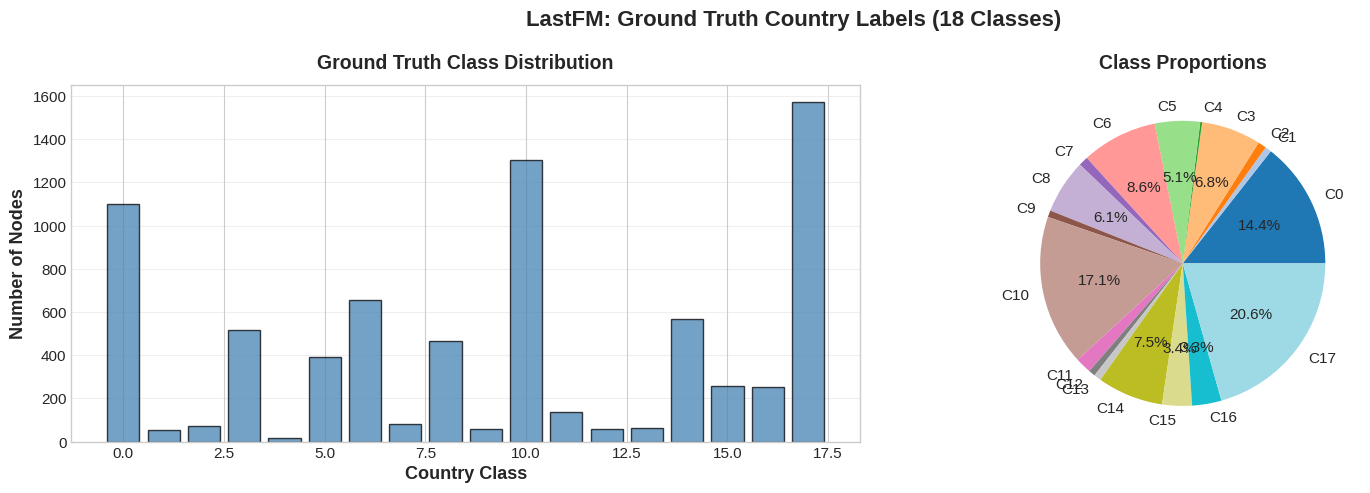

Class sizes: min=16 (class 4), max=1572 (class 17)
Imbalance ratio: 98.2x


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(range(n_classes), class_counts, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].set_xlabel('Country Class', fontsize=13)
axes[0].set_ylabel('Number of Nodes', fontsize=13)
axes[0].set_title('Ground Truth Class Distribution', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Class balance info
axes[1].pie(class_counts, labels=[f'C{i}' for i in range(n_classes)],
            autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
            colors=plt.cm.tab20(np.linspace(0, 1, n_classes)))
axes[1].set_title('Class Proportions', fontsize=14, pad=12)

plt.suptitle('LastFM: Ground Truth Country Labels (18 Classes)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class sizes: min={class_counts.min()} (class {class_counts.argmin()}), "
      f"max={class_counts.max()} (class {class_counts.argmax()})")
print(f"Imbalance ratio: {class_counts.max() / class_counts.min():.1f}x")

---

## 3. Spectral Clustering

### Why Spectral Clustering?

We start with spectral clustering because it is the most mathematically grounded approach to community detection covered in our lectures. It takes the graph and turns the problem of finding communities into a simpler geometry problem using eigenvalues.

### How It Works (Simple Version)

1. We build the **Laplacian matrix** from the graph (this captures the connection patterns)
2. We compute its eigenvalues and eigenvectors (these reveal the natural groupings in the graph)
3. We use the **eigengap heuristic** to guess how many clusters there are (if there is a big jump between eigenvalue k and k+1, that suggests k clusters)
4. We take the first k eigenvectors as node embeddings and run K-means on them

### Why This Makes Sense Here

Spectral clustering is a good first step because:
- It uses **only graph structure** (no features needed), so it gives us a clean structure-only baseline
- It is deterministic and well-understood mathematically, unlike neural network methods
- The eigengap heuristic tells us how many natural clusters the graph has, which is useful to know before we try other methods
- It was directly covered in the shallow embeddings lecture as the Laplacian Eigenmaps approach

We try two values of k: the one suggested by the eigengap heuristic, and k=18 (the actual number of countries) to see how well the graph structure alone can recover the true labels.

---


In [36]:
# Build adjacency matrix (sparse, consistent node ordering)
A = nx.adjacency_matrix(G, nodelist=nodes)
degrees = np.array(A.sum(axis=1)).flatten()

# Unnormalized Laplacian: L = D - A
D_mat = diags(degrees)
L_unnorm = D_mat - A

# Symmetric normalized Laplacian: L_sym = I - D^{-1/2} A D^{-1/2}
D_inv_sqrt = diags(1.0 / np.sqrt(np.maximum(degrees, 1e-12)))
L_sym = speye(n_nodes) - D_inv_sqrt @ A @ D_inv_sqrt

print("=== Laplacian Matrices ===")
print(f"Unnormalized L: {L_unnorm.shape}, nnz = {L_unnorm.nnz:,}")
print(f"Symmetric normalized L_sym: {L_sym.shape}, nnz = {L_sym.nnz:,}")

# Verify properties
print(f"\nMin degree: {degrees.min():.0f}, Max degree: {degrees.max():.0f}")
print("L is positive semi-definite (all eigenvalues >= 0)")
print("Spectrum of L_sym is bounded in [0, 2]")

=== Laplacian Matrices ===
Unnormalized L: (7624, 7624), nnz = 63,236
Symmetric normalized L_sym: (7624, 7624), nnz = 63,236

Min degree: 1, Max degree: 216
L is positive semi-definite (all eigenvalues >= 0)
Spectrum of L_sym is bounded in [0, 2]


Computing 50 smallest eigenvalues of L_sym...
Done in 0.6s


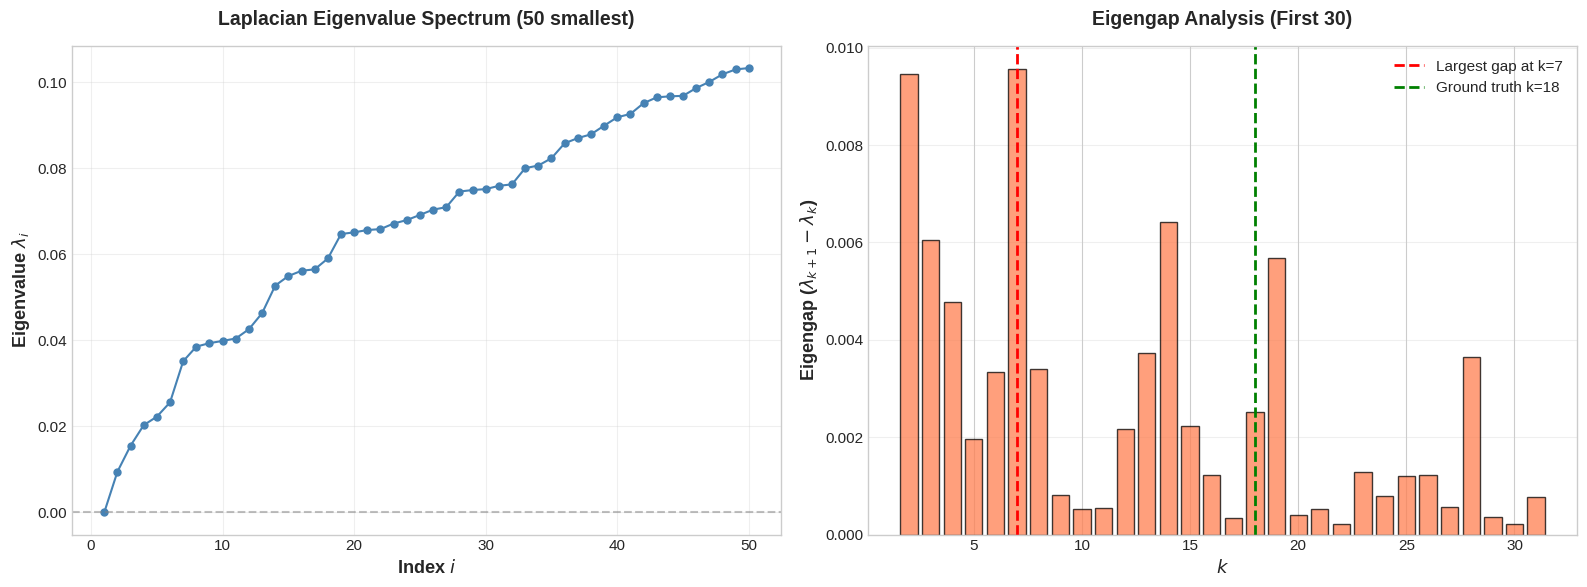


Eigengap heuristic suggests k = 7 clusters
Ground truth has k = 18 classes
First 10 eigenvalues: [0.       0.009451 0.01551  0.020293 0.022264 0.025593 0.035153 0.038557
 0.039363 0.039885]

The algebraic connectivity (Fiedler value) lambda_2 = 0.009451
Small Fiedler value indicates a sparse cut (bottleneck) exists.


In [37]:
# Compute the 50 smallest eigenvalues of L_sym
n_eigs = 50
print(f"Computing {n_eigs} smallest eigenvalues of L_sym...")
t0 = time.time()
eigenvalues, eigenvectors = eigsh(L_sym, k=n_eigs, which='SM')
print(f"Done in {time.time()-t0:.1f}s")

# Sort by eigenvalue
idx_sorted = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx_sorted]
eigenvectors = eigenvectors[:, idx_sorted]

# Eigengap analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Eigenvalue spectrum
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='steelblue',
             markersize=5, linewidth=1.5)
axes[0].set_xlabel('Index $i$', fontsize=13)
axes[0].set_ylabel('Eigenvalue $\lambda_i$', fontsize=13)
axes[0].set_title('Laplacian Eigenvalue Spectrum (50 smallest)', fontsize=14, pad=15)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Eigengap: lambda_{k+1} - lambda_k
eigengaps = np.diff(eigenvalues)
axes[1].bar(range(2, min(30, len(eigengaps))+2), eigengaps[:min(30, len(eigengaps))],
            color='coral', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('$k$', fontsize=13)
axes[1].set_ylabel('Eigengap ($\lambda_{k+1} - \lambda_k$)', fontsize=13)
axes[1].set_title('Eigengap Analysis (First 30)', fontsize=14, pad=15)
axes[1].grid(True, alpha=0.3, axis='y')

# Mark largest gap in first 25
best_k = np.argmax(eigengaps[:25]) + 2
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=2,
                label=f'Largest gap at k={best_k}')
axes[1].axvline(n_classes, color='green', linestyle='--', linewidth=2,
                label=f'Ground truth k={n_classes}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nEigengap heuristic suggests k = {best_k} clusters")
print(f"Ground truth has k = {n_classes} classes")
print(f"First 10 eigenvalues: {eigenvalues[:10].round(6)}")
print(f"\nThe algebraic connectivity (Fiedler value) lambda_2 = {eigenvalues[1]:.6f}")
if eigenvalues[1] < 0.01:
    print("Small Fiedler value indicates a sparse cut (bottleneck) exists.")
else:
    print("Moderate Fiedler value suggests no extremely weak bottleneck.")

In [38]:
# Spectral embedding: use k smallest non-trivial eigenvectors
# We try both the eigengap-suggested k and the ground truth k

results_spectral = {}

for k_val, label in [(best_k, f'Eigengap (k={best_k})'), (n_classes, f'GT-matched (k={n_classes})')]:
    # Skip trivial eigenvector (index 0, eigenvalue ~0)
    embedding = eigenvectors[:, 1:k_val+1]

    # Row-normalize (Ng, Jordan, Weiss 2002)
    embedding_norm = normalize(embedding, norm='l2', axis=1)

    # K-means
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(embedding_norm)

    # Store
    results_spectral[label] = {
        'k': k_val,
        'labels': labels,
        'embedding': embedding_norm,
        'inertia': kmeans.inertia_
    }

    # Metrics
    communities = defaultdict(set)
    for i, lab in enumerate(labels):
        communities[lab].add(nodes[i])
    comm_list = list(communities.values())

    mod = nx_community.modularity(G, comm_list)
    nmi = normalized_mutual_info_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)

    results_spectral[label]['modularity'] = mod
    results_spectral[label]['nmi'] = nmi
    results_spectral[label]['ari'] = ari
    results_spectral[label]['ami'] = ami

    print(f"\n=== Spectral Clustering: {label} ===")
    print(f"Clusters: {k_val}, Sizes: {sorted(Counter(labels).values(), reverse=True)[:10]}...")
    print(f"Modularity: {mod:.4f}")
    print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, AMI: {ami:.4f}")


=== Spectral Clustering: Eigengap (k=7) ===
Clusters: 7, Sizes: [1770, 1732, 1477, 1142, 656, 621, 226]...
Modularity: 0.7641
NMI: 0.5966, ARI: 0.5584, AMI: 0.5952

=== Spectral Clustering: GT-matched (k=18) ===
Clusters: 18, Sizes: [1487, 1145, 1099, 980, 542, 514, 410, 306, 221, 170]...
Modularity: 0.7992
NMI: 0.6586, ARI: 0.6714, AMI: 0.6557


Computing t-SNE projection of spectral embeddings...


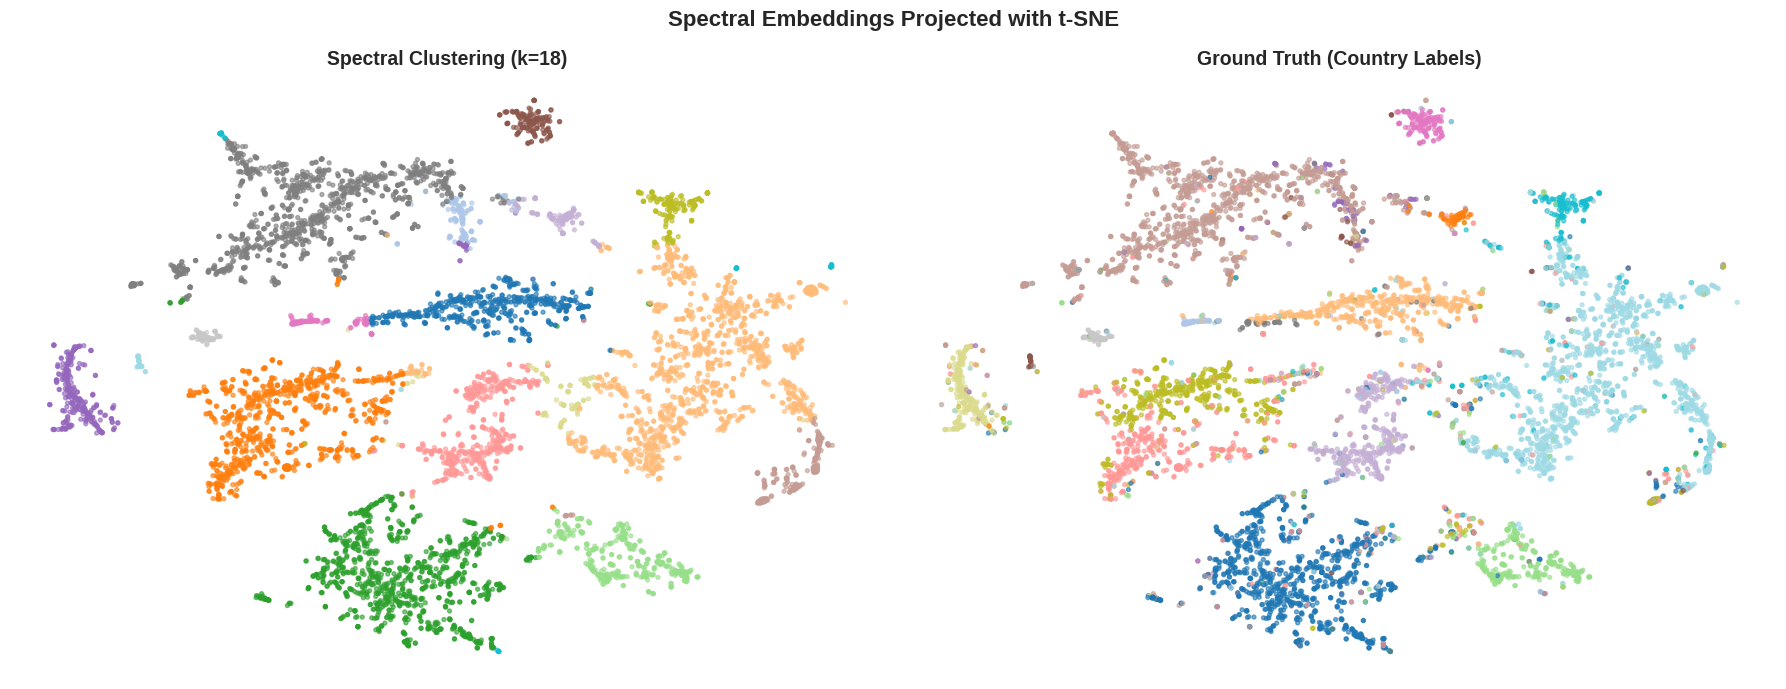

In [39]:
# t-SNE visualization of spectral embeddings (GT-matched k)
spec_key = f'GT-matched (k={n_classes})'
spec_emb = results_spectral[spec_key]['embedding']
spec_labels = results_spectral[spec_key]['labels']

print("Computing t-SNE projection of spectral embeddings...")
tsne_spec = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
spec_2d = tsne_spec.fit_transform(spec_emb)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter1 = axes[0].scatter(spec_2d[:, 0], spec_2d[:, 1],
                           c=spec_labels, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title(f'Spectral Clustering (k={n_classes})', fontsize=14, fontweight='bold')
axes[0].axis('off')

scatter2 = axes[1].scatter(spec_2d[:, 0], spec_2d[:, 1],
                           c=y, cmap='tab20', s=8, alpha=0.6)
axes[1].set_title('Ground Truth (Country Labels)', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Spectral Embeddings Projected with t-SNE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Node2Vec: Shallow Embeddings via Biased Random Walks

### Why Node2Vec?

After spectral clustering, we move to Node2Vec because it is the main shallow embedding method from our lectures. While spectral clustering uses eigenvalues directly, Node2Vec takes a different approach: it learns embeddings by doing random walks on the graph and then training a Word2Vec model on those walks.

### How It Works (Simple Version)

1. Start at each node and take a bunch of random walks through the graph
2. The walks are **biased** by two parameters, p and q, which control whether the walk stays local (BFS-like) or explores further out (DFS-like)
3. Treat these walks like sentences and nodes like words, then train Word2Vec to learn an embedding for each node
4. Nodes that appear in similar walk contexts end up with similar embeddings

### Why We Try Two Configurations

We test two settings because the p and q parameters have a big effect on what kind of structure the embeddings capture:

- **BFS-biased (p=1, q=2):** The walk tends to stay close to the starting node. This captures local neighborhood structure - good for finding tight-knit groups.
- **DFS-biased (p=2, q=0.5):** The walk tends to explore further away. This captures broader community membership - good for finding nodes that belong to the same global community even if they are not directly connected.

By comparing both, we can see which type of structure matters more for community detection in this network. The lectures taught us that BFS captures structural equivalence while DFS captures homophily, so this comparison directly tests which of those properties is more relevant here.

---


In [40]:
def node2vec_walk(G, start, walk_length, p, q, neighbors_dict):
    """Generate a single biased 2nd-order random walk."""
    walk = [start]

    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = neighbors_dict.get(cur, [])

        if not neighbors:
            break

        if len(walk) == 1:
            walk.append(random.choice(neighbors))
        else:
            prev = walk[-2]
            prev_neighbors = set(neighbors_dict.get(prev, []))

            weights = []
            for nbr in neighbors:
                if nbr == prev:
                    weights.append(1.0 / p)   # Return to previous
                elif nbr in prev_neighbors:
                    weights.append(1.0)        # Neighbor of previous (stay close)
                else:
                    weights.append(1.0 / q)    # Move outward (explore)

            walk.append(random.choices(neighbors, weights=weights, k=1)[0])

    return walk


def generate_walks(G, num_walks=10, walk_length=80, p=1.0, q=1.0, seed=42):
    """Generate biased random walks for all nodes in the graph."""
    random.seed(seed)
    nodes_list = list(G.nodes())

    # Pre-compute neighbor lists for efficiency
    neighbors_dict = {n: list(G.neighbors(n)) for n in nodes_list}

    walks = []
    for walk_num in range(num_walks):
        random.shuffle(nodes_list)
        for node in nodes_list:
            walk = node2vec_walk(G, node, walk_length, p, q, neighbors_dict)
            walks.append([str(w) for w in walk])

        if (walk_num + 1) % 2 == 0:
            print(f"  Completed walk iteration {walk_num+1}/{num_walks}")

    return walks


def train_node2vec(G, num_walks=10, walk_length=80, p=1.0, q=1.0,
                   vector_size=128, window=10, epochs=5, seed=42):
    """Full Node2Vec pipeline: walks + Word2Vec training."""
    print(f"Generating walks (p={p}, q={q})...")
    t0 = time.time()
    walks = generate_walks(G, num_walks, walk_length, p, q, seed)
    print(f"  Generated {len(walks):,} walks in {time.time()-t0:.1f}s")

    print("Training Word2Vec Skip-Gram...")
    t0 = time.time()
    model = Word2Vec(
        walks,
        vector_size=vector_size,
        window=window,
        min_count=0,
        sg=1,          # Skip-gram
        workers=4,
        epochs=epochs,
        seed=seed
    )
    print(f"  Training complete in {time.time()-t0:.1f}s")

    return model

print("Node2Vec functions defined.")

Node2Vec functions defined.


In [41]:
# Configuration 1: BFS-biased (p=1, q=2) - captures local community structure
model_bfs = train_node2vec(G, num_walks=10, walk_length=80, p=1.0, q=2.0,
                           vector_size=128, window=10, epochs=5)

# Extract embeddings
n2v_bfs = np.array([model_bfs.wv[str(n)] for n in nodes])
print(f"\nNode2Vec BFS embedding shape: {n2v_bfs.shape}")

Generating walks (p=1.0, q=2.0)...
  Completed walk iteration 2/10
  Completed walk iteration 4/10
  Completed walk iteration 6/10
  Completed walk iteration 8/10
  Completed walk iteration 10/10
  Generated 76,240 walks in 22.2s
Training Word2Vec Skip-Gram...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Training complete in 54.2s

Node2Vec BFS embedding shape: (7624, 128)


In [42]:
# Configuration 2: DFS-biased (p=2, q=0.5) - captures global/homophily structure
model_dfs = train_node2vec(G, num_walks=10, walk_length=80, p=2.0, q=0.5,
                           vector_size=128, window=10, epochs=5)

# Extract embeddings
n2v_dfs = np.array([model_dfs.wv[str(n)] for n in nodes])
print(f"\nNode2Vec DFS embedding shape: {n2v_dfs.shape}")

Generating walks (p=2.0, q=0.5)...
  Completed walk iteration 2/10
  Completed walk iteration 4/10
  Completed walk iteration 6/10
  Completed walk iteration 8/10
  Completed walk iteration 10/10
  Generated 76,240 walks in 21.3s
Training Word2Vec Skip-Gram...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Training complete in 58.2s

Node2Vec DFS embedding shape: (7624, 128)


Computing t-SNE projections...


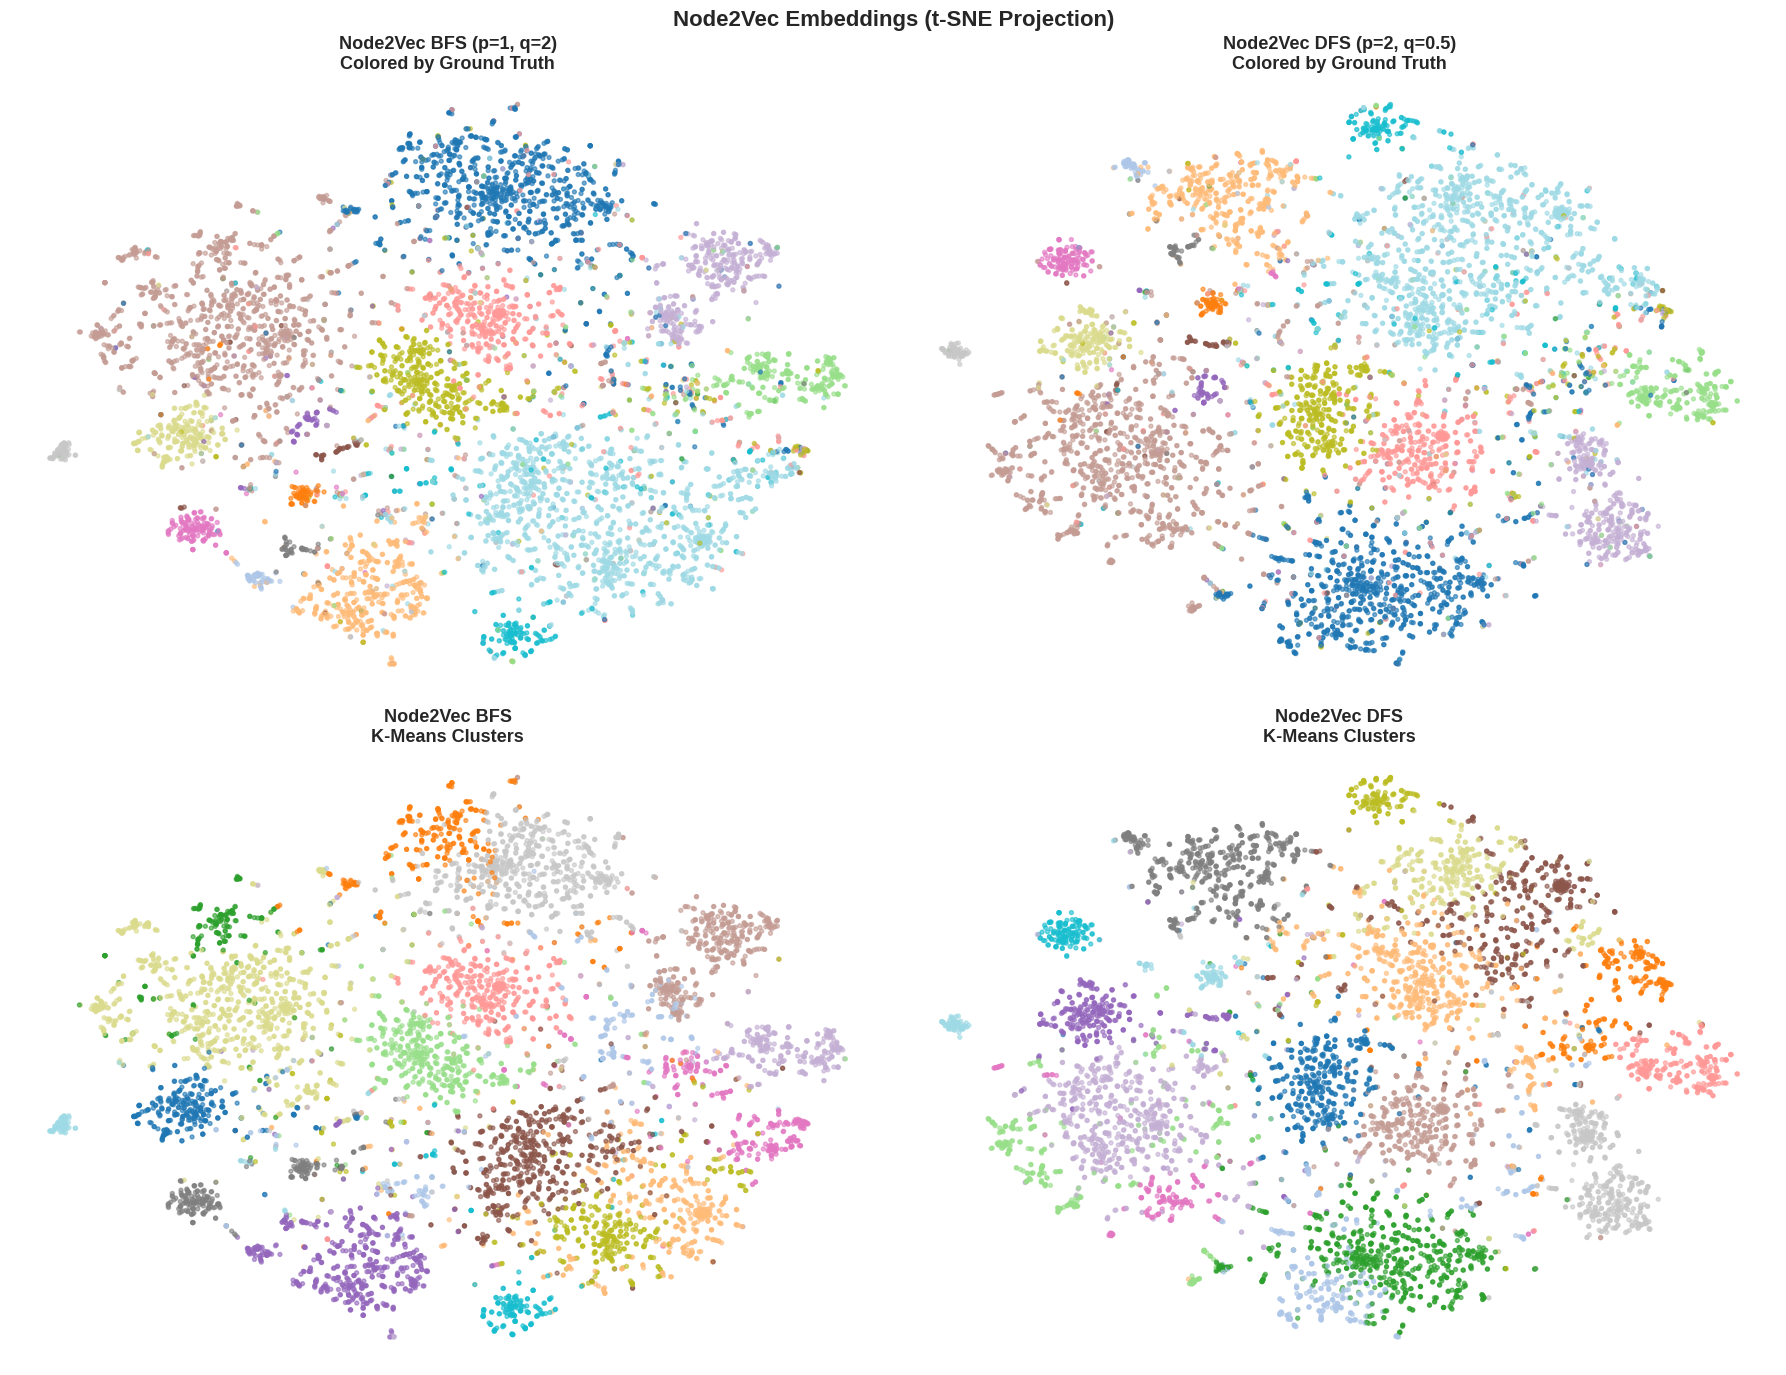

In [43]:
# t-SNE visualization for both Node2Vec configurations
print("Computing t-SNE projections...")

tsne_bfs = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
bfs_2d = tsne_bfs.fit_transform(n2v_bfs)

tsne_dfs = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
dfs_2d = tsne_dfs.fit_transform(n2v_dfs)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# BFS embeddings
axes[0, 0].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=y, cmap='tab20', s=8, alpha=0.6)
axes[0, 0].set_title('Node2Vec BFS (p=1, q=2)\nColored by Ground Truth', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].scatter(dfs_2d[:, 0], dfs_2d[:, 1], c=y, cmap='tab20', s=8, alpha=0.6)
axes[0, 1].set_title('Node2Vec DFS (p=2, q=0.5)\nColored by Ground Truth', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# K-means on both
kmeans_bfs = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
labels_bfs = kmeans_bfs.fit_predict(n2v_bfs)

kmeans_dfs = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
labels_dfs = kmeans_dfs.fit_predict(n2v_dfs)

axes[1, 0].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=labels_bfs, cmap='tab20', s=8, alpha=0.6)
axes[1, 0].set_title('Node2Vec BFS\nK-Means Clusters', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].scatter(dfs_2d[:, 0], dfs_2d[:, 1], c=labels_dfs, cmap='tab20', s=8, alpha=0.6)
axes[1, 1].set_title('Node2Vec DFS\nK-Means Clusters', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Node2Vec Embeddings (t-SNE Projection)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# Evaluate both Node2Vec configurations
results_n2v = {}

for name, labels, embeddings in [('Node2Vec BFS (p=1,q=2)', labels_bfs, n2v_bfs),
                                   ('Node2Vec DFS (p=2,q=0.5)', labels_dfs, n2v_dfs)]:
    communities = defaultdict(set)
    for i, lab in enumerate(labels):
        communities[lab].add(nodes[i])
    comm_list = list(communities.values())

    mod = nx_community.modularity(G, comm_list)
    nmi = normalized_mutual_info_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)

    results_n2v[name] = {
        'labels': labels, 'modularity': mod,
        'nmi': nmi, 'ari': ari, 'ami': ami,
        'n_clusters': n_classes
    }

    print(f"\n=== {name} ===")
    print(f"Modularity: {mod:.4f}")
    print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, AMI: {ami:.4f}")


=== Node2Vec BFS (p=1,q=2) ===
Modularity: 0.7816
NMI: 0.6171, ARI: 0.5024, AMI: 0.6141

=== Node2Vec DFS (p=2,q=0.5) ===
Modularity: 0.7844
NMI: 0.6107, ARI: 0.4549, AMI: 0.6077


---

## 5. GCN for Node Classification

### Why GCN?

After trying spectral clustering (math-based) and Node2Vec (random walk-based), we now move to Graph Convolutional Networks (GCN). The reason is simple: GCN is the only method here that can use **both** the graph structure **and** the node features (artist preferences). Spectral clustering and Node2Vec only use structure.

Since the LastFM dataset has rich node features (7,842 artist preferences per user), we want to see if adding that information improves community detection compared to structure-only methods.

### How It Works (Simple Version)

A GCN works by **message passing**: each node looks at its neighbors, collects their information, and combines it with its own. After a few rounds of this, each node has a representation that captures both its own features and the features of its local neighborhood.

For node classification, we train the GCN to predict each user's country based on their features and their neighbors' features. The idea is that if users from the same country tend to be connected and listen to similar artists, the GCN should be able to learn this pattern.

### Our Setup

- **Architecture:** 2-layer GCN (128-dim input from SVD-reduced features -> 64-dim hidden -> 18-class output)
- **Train/Val/Test split:** We split the nodes (not edges) so the GCN can train on some labeled nodes and predict the rest
- **Why this architecture:** We keep it simple (2 layers, 64 hidden dims) as a starting point. The GCN lecture showed that 2-3 layers is usually enough for most graphs since information spreads quickly through message passing.

---


In [45]:
# Build normalized adjacency matrix: A_hat = D_tilde^{-1/2} A_tilde D_tilde^{-1/2}
A_adj = nx.adjacency_matrix(G, nodelist=nodes).astype(np.float32)
A_tilde = A_adj + speye(n_nodes, format='csr')  # Add self-loops
D_tilde_vals = np.array(A_tilde.sum(axis=1)).flatten()
D_tilde_inv_sqrt = diags(1.0 / np.sqrt(np.maximum(D_tilde_vals, 1e-12)))
A_hat_scipy = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

# Convert scipy sparse -> torch sparse
def scipy_to_torch_sparse(sp_matrix):
    coo = sp_matrix.tocoo().astype(np.float32)
    indices = torch.LongTensor(np.vstack([coo.row, coo.col]))
    values = torch.FloatTensor(coo.data)
    return torch.sparse_coo_tensor(indices, values, coo.shape)

A_hat_tensor = scipy_to_torch_sparse(A_hat_scipy).to(device)
X_tensor = torch.FloatTensor(X_reduced).to(device)   # SVD-reduced features (128-dim)
y_tensor = torch.LongTensor(y).to(device)

# Train/val/test split (node masking strategy from the lecture)
n_train = int(0.6 * n_nodes)
n_val = int(0.2 * n_nodes)

np.random.seed(42)
perm = np.random.permutation(n_nodes)
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[perm[:n_train]] = True
val_mask[perm[n_train:n_train+n_val]] = True
test_mask[perm[n_train+n_val:]] = True

print("=== GCN Data Preparation ===")
print(f"Feature input dim: {X_reduced.shape[1]}")
print(f"Output classes: {n_classes}")
print(f"A_hat: sparse tensor, {A_hat_tensor.shape}")
print(f"Train: {train_mask.sum().item()}, Val: {val_mask.sum().item()}, Test: {test_mask.sum().item()}")

=== GCN Data Preparation ===
Feature input dim: 128
Output classes: 18
A_hat: sparse tensor, torch.Size([7624, 7624])
Train: 4574, Val: 1524, Test: 1526


In [46]:
class GCNLayer(nn.Module):
    """Single Graph Convolutional Layer: H' = A_hat @ H @ W"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, H, A_hat):
        support = H @ self.weight          # (n, out_features)
        output = torch.sparse.mm(A_hat, support)  # Message passing
        return output + self.bias


class GCN(nn.Module):
    """2-layer Graph Convolutional Network for node classification."""
    def __init__(self, in_features, hidden_dim, out_features, dropout=0.5):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, out_features)
        self.dropout = dropout

    def forward(self, X, A_hat):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, self.dropout, training=self.training)
        out = self.gc2(h, A_hat)
        return out

    def get_embedding(self, X, A_hat):
        """Extract hidden layer embeddings (before classification head)."""
        with torch.no_grad():
            h = F.relu(self.gc1(X, A_hat))
        return h


# Instantiate model
model_gcn = GCN(
    in_features=X_reduced.shape[1],
    hidden_dim=64,
    out_features=n_classes,
    dropout=0.5
).to(device)

optimizer_gcn = Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"GCN architecture: {X_reduced.shape[1]} -> 64 -> {n_classes}")
print(f"Total parameters: {total_params:,}")

GCN architecture: 128 -> 64 -> 18
Total parameters: 9,426


In [47]:
def train_gcn_epoch(model, X, A_hat, y, train_mask, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(X, A_hat)
    loss = F.cross_entropy(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def eval_gcn(model, X, A_hat, y, mask):
    model.eval()
    out = model(X, A_hat)
    pred = out[mask].argmax(dim=1)
    acc = (pred == y[mask]).float().mean().item()
    loss = F.cross_entropy(out[mask], y[mask]).item()
    return acc, loss


# Training
n_epochs = 200
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_epoch = 0

print("Training GCN for node classification...")
for epoch in range(1, n_epochs + 1):
    train_loss = train_gcn_epoch(model_gcn, X_tensor, A_hat_tensor, y_tensor, train_mask, optimizer_gcn)
    train_acc, _ = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, train_mask)
    val_acc, val_loss = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, val_mask)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in model_gcn.state_dict().items()}

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Restore best model
model_gcn.load_state_dict(best_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

Training GCN for node classification...
  Epoch  50 | Train Loss: 0.4303 | Train Acc: 0.9049 | Val Acc: 0.8596
  Epoch 100 | Train Loss: 0.3198 | Train Acc: 0.9300 | Val Acc: 0.8714
  Epoch 150 | Train Loss: 0.2836 | Train Acc: 0.9399 | Val Acc: 0.8714
  Epoch 200 | Train Loss: 0.2642 | Train Acc: 0.9434 | Val Acc: 0.8740

Best validation accuracy: 0.8786 at epoch 106


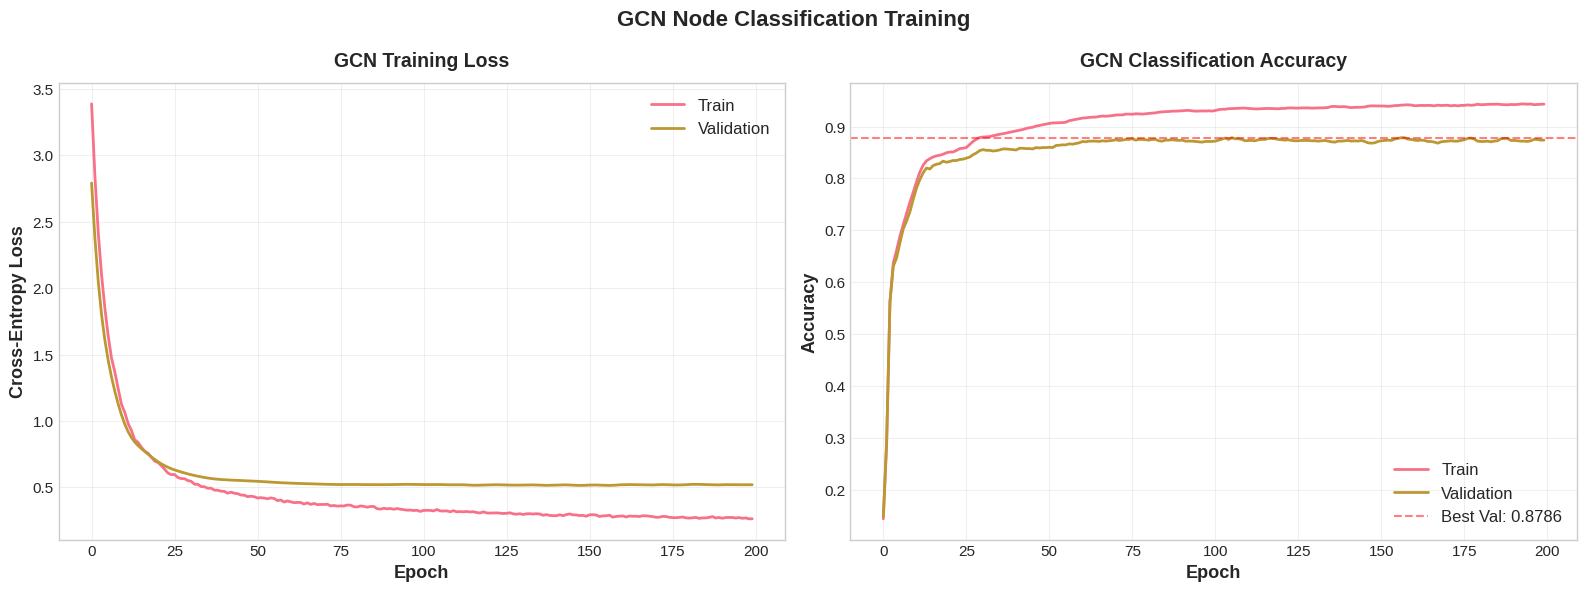

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=13)
axes[0].set_title('GCN Training Loss', fontsize=14, pad=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
axes[1].axhline(best_val_acc, color='red', linestyle='--', alpha=0.5,
                label=f'Best Val: {best_val_acc:.4f}')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Accuracy', fontsize=13)
axes[1].set_title('GCN Classification Accuracy', fontsize=14, pad=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN Node Classification Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# Final test evaluation
test_acc, test_loss = eval_gcn(model_gcn, X_tensor, A_hat_tensor, y_tensor, test_mask)

model_gcn.eval()
with torch.no_grad():
    logits = model_gcn(X_tensor, A_hat_tensor)
    test_pred = logits[test_mask].argmax(dim=1).cpu().numpy()
    test_true = y_tensor[test_mask].cpu().numpy()

print("=== GCN Test Results ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"\nMacro F1: {f1_score(test_true, test_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(test_true, test_pred, average='weighted'):.4f}")
print(f"\n--- Classification Report (Test Set) ---")
print(classification_report(test_true, test_pred, zero_division=0))

=== GCN Test Results ===
Test Accuracy: 0.8952
Test Loss: 0.4682

Macro F1: 0.8227
Weighted F1: 0.8925

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       213
           1       1.00      0.60      0.75         5
           2       0.94      0.88      0.91        17
           3       0.89      0.94      0.91       112
           4       0.00      0.00      0.00         5
           5       0.96      0.82      0.89        85
           6       0.83      0.78      0.81       129
           7       1.00      0.70      0.82        20
           8       0.93      0.94      0.93        93
           9       0.88      0.70      0.78        10
          10       0.90      0.97      0.93       230
          11       1.00      0.87      0.93        30
          12       0.92      0.79      0.85        14
          13       1.00      0.85      0.92        13
          14       0.86      0.86      0.86 

GCN embedding shape: (7624, 64)
Computing t-SNE of GCN embeddings...


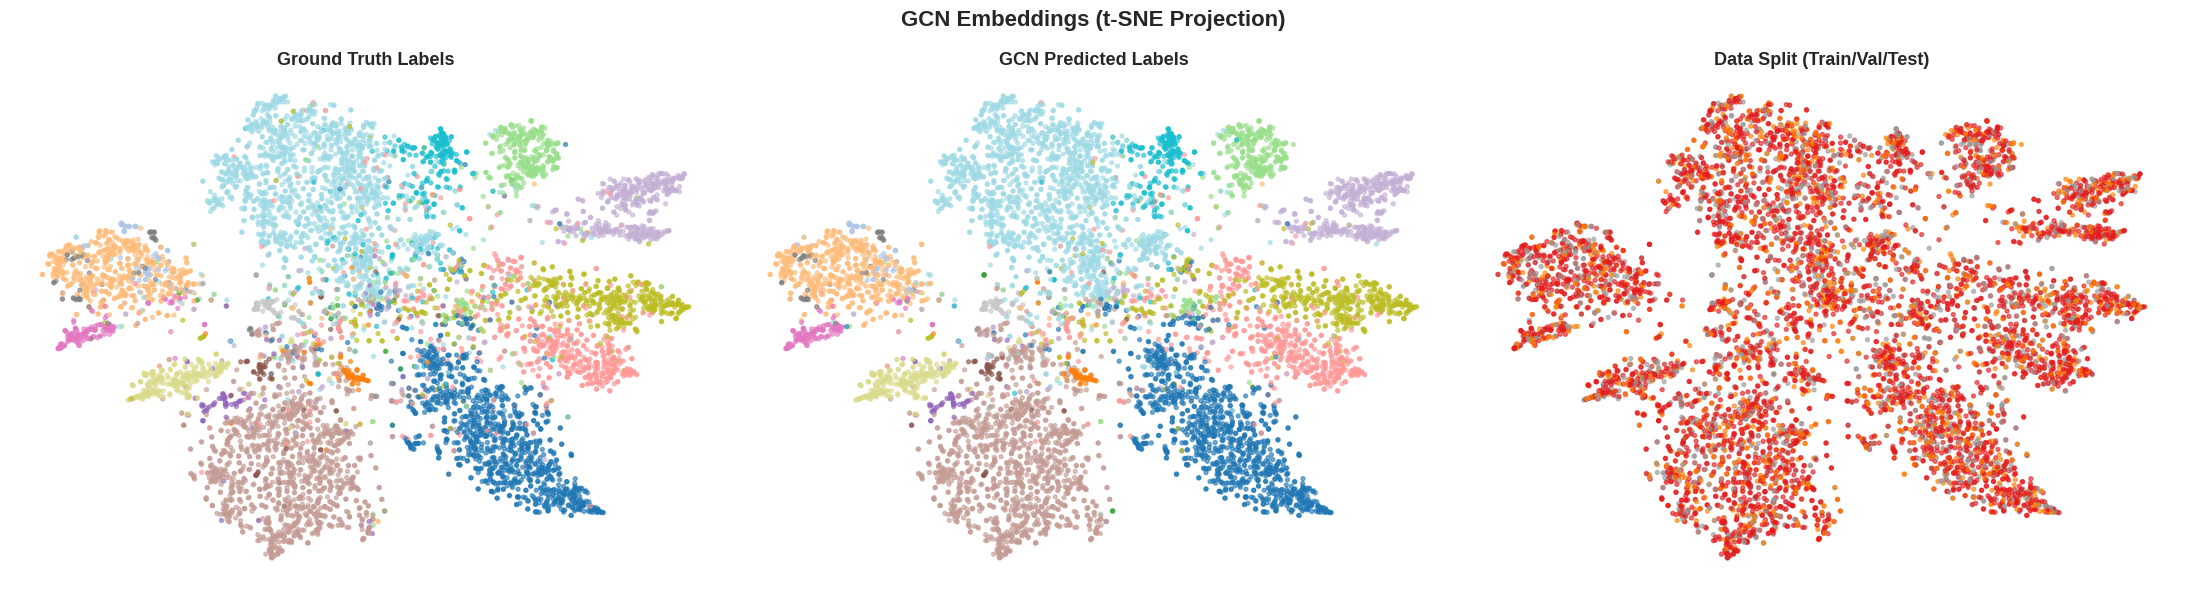

In [50]:
# Extract GCN hidden layer embeddings
model_gcn.eval()
gcn_embeddings = model_gcn.get_embedding(X_tensor, A_hat_tensor).cpu().numpy()
print(f"GCN embedding shape: {gcn_embeddings.shape}")

# t-SNE visualization
print("Computing t-SNE of GCN embeddings...")
tsne_gcn = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
gcn_2d = tsne_gcn.fit_transform(gcn_embeddings)

# Also get predicted labels for all nodes
with torch.no_grad():
    all_pred = model_gcn(X_tensor, A_hat_tensor).argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=y, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title('Ground Truth Labels', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=all_pred, cmap='tab20', s=8, alpha=0.6)
axes[1].set_title('GCN Predicted Labels', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Color by train/val/test split
split_colors = np.zeros(n_nodes)
split_colors[train_mask.numpy()] = 0
split_colors[val_mask.numpy()] = 1
split_colors[test_mask.numpy()] = 2
axes[2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=split_colors, cmap='Set1', s=8, alpha=0.6)
axes[2].set_title('Data Split (Train/Val/Test)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('GCN Embeddings (t-SNE Projection)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Link Prediction with GNN

### Why Link Prediction?

We add link prediction as a second GNN task because it gives us a different kind of embedding. While node classification learns embeddings that separate classes, link prediction learns embeddings where connected nodes are close together. This is more directly related to community structure.

### How It Works (Simple Version)

1. We hide some edges from the graph (test edges) and train the GCN on the remaining edges
2. The GCN learns node embeddings from the partial graph
3. To predict if an edge exists between two nodes, we take the dot product of their embeddings - if the score is high, the model thinks they should be connected
4. We also sample random non-edges as negative examples, so the model learns to tell real edges from fake ones

### Why This Matters for Community Detection

The embeddings from link prediction should capture who is likely connected to who. Since community structure is all about connection patterns, we expect these embeddings to be useful for community detection too. We will later apply K-means to these embeddings and compare with the other methods.

---


In [51]:
# Split edges into train/val/test
random.seed(42)
np.random.seed(42)

all_edges = list(G.edges())
random.shuffle(all_edges)

n_test_edges = int(0.1 * len(all_edges))
n_val_edges = int(0.1 * len(all_edges))

test_pos_edges = all_edges[:n_test_edges]
val_pos_edges = all_edges[n_test_edges:n_test_edges + n_val_edges]
train_pos_edges = all_edges[n_test_edges + n_val_edges:]

# Build training graph (message passing uses only train edges)
G_train_lp = nx.Graph()
G_train_lp.add_nodes_from(nodes)
G_train_lp.add_edges_from(train_pos_edges)

# Negative sampling
existing_edges = set(G.edges()) | set((v, u) for u, v in G.edges())
nodes_list = list(nodes)

def sample_negatives(n_samples, exclude_set, seed=None):
    if seed is not None:
        random.seed(seed)
    neg = []
    while len(neg) < n_samples:
        u = random.choice(nodes_list)
        v = random.choice(nodes_list)
        if u != v and (u, v) not in exclude_set and (v, u) not in exclude_set:
            neg.append((u, v))
            exclude_set.add((u, v))
    return neg

test_neg_edges = sample_negatives(n_test_edges, existing_edges.copy(), seed=42)
val_neg_edges = sample_negatives(n_val_edges, existing_edges.copy(), seed=43)
train_neg_edges = sample_negatives(len(train_pos_edges), existing_edges.copy(), seed=44)

# Compute A_hat for training graph
A_train_adj = nx.adjacency_matrix(G_train_lp, nodelist=nodes).astype(np.float32)
A_tilde_train = A_train_adj + speye(n_nodes, format='csr')
D_tilde_train_vals = np.array(A_tilde_train.sum(axis=1)).flatten()
D_inv_sqrt_train = diags(1.0 / np.sqrt(np.maximum(D_tilde_train_vals, 1e-12)))
A_hat_train_scipy = D_inv_sqrt_train @ A_tilde_train @ D_inv_sqrt_train
A_hat_train_tensor = scipy_to_torch_sparse(A_hat_train_scipy).to(device)

# Convert edges to index tensors
def edges_to_indices(edge_list):
    src = torch.LongTensor([node_to_idx[u] for u, v in edge_list])
    dst = torch.LongTensor([node_to_idx[v] for u, v in edge_list])
    return torch.stack([src, dst]).to(device)

train_pos_idx = edges_to_indices(train_pos_edges)
train_neg_idx = edges_to_indices(train_neg_edges)
val_pos_idx = edges_to_indices(val_pos_edges)
val_neg_idx = edges_to_indices(val_neg_edges)
test_pos_idx = edges_to_indices(test_pos_edges)
test_neg_idx = edges_to_indices(test_neg_edges)

print("=== Link Prediction Edge Split ===")
print(f"Total edges: {len(all_edges):,}")
print(f"Train: {len(train_pos_edges):,} pos + {len(train_neg_edges):,} neg")
print(f"Val:   {n_val_edges:,} pos + {len(val_neg_edges):,} neg")
print(f"Test:  {n_test_edges:,} pos + {len(test_neg_edges):,} neg")
print(f"Training graph density: {nx.density(G_train_lp):.6f}")

=== Link Prediction Edge Split ===
Total edges: 27,806
Train: 22,246 pos + 22,246 neg
Val:   2,780 pos + 2,780 neg
Test:  2,780 pos + 2,780 neg
Training graph density: 0.000766


In [52]:
class GCNLinkPredictor(nn.Module):
    """GCN encoder + dot product decoder for link prediction."""
    def __init__(self, in_features, hidden_dim, emb_dim, dropout=0.3):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, emb_dim)
        self.dropout = dropout

    def encode(self, X, A_hat):
        h = F.relu(self.gc1(X, A_hat))
        h = F.dropout(h, self.dropout, training=self.training)
        z = self.gc2(h, A_hat)
        return z

    def decode(self, z, edge_index):
        """Dot product decoder: score = z_u^T * z_v"""
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)

    def forward(self, X, A_hat, pos_edge_index, neg_edge_index):
        z = self.encode(X, A_hat)
        pos_score = self.decode(z, pos_edge_index)
        neg_score = self.decode(z, neg_edge_index)
        return pos_score, neg_score


model_lp = GCNLinkPredictor(
    in_features=X_reduced.shape[1],
    hidden_dim=128,
    emb_dim=64,
    dropout=0.3
).to(device)

optimizer_lp = Adam(model_lp.parameters(), lr=0.01, weight_decay=1e-5)

print(f"Link Predictor: {X_reduced.shape[1]} -> 128 -> 64")
print(f"Parameters: {sum(p.numel() for p in model_lp.parameters()):,}")

Link Predictor: 128 -> 128 -> 64
Parameters: 24,768


In [53]:
def train_lp_epoch(model, X, A_hat, pos_idx, neg_idx, optimizer):
    model.train()
    optimizer.zero_grad()

    pos_score, neg_score = model(X, A_hat, pos_idx, neg_idx)

    # Binary cross-entropy loss
    pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()
    neg_loss = -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()
    loss = pos_loss + neg_loss

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def eval_lp(model, X, A_hat, pos_idx, neg_idx):
    model.eval()
    pos_score, neg_score = model(X, A_hat, pos_idx, neg_idx)

    pos_probs = torch.sigmoid(pos_score).cpu().numpy()
    neg_probs = torch.sigmoid(neg_score).cpu().numpy()

    y_true = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])
    y_score = np.concatenate([pos_probs, neg_probs])

    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    return auc, ap


# Training
n_epochs_lp = 200
lp_history = {'loss': [], 'val_auc': [], 'val_ap': []}
best_val_auc = 0

print("Training GCN Link Predictor...")
for epoch in range(1, n_epochs_lp + 1):
    loss = train_lp_epoch(model_lp, X_tensor, A_hat_train_tensor,
                          train_pos_idx, train_neg_idx, optimizer_lp)
    val_auc, val_ap = eval_lp(model_lp, X_tensor, A_hat_train_tensor,
                               val_pos_idx, val_neg_idx)

    lp_history['loss'].append(loss)
    lp_history['val_auc'].append(val_auc)
    lp_history['val_ap'].append(val_ap)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_lp_state = {k: v.clone() for k, v in model_lp.state_dict().items()}

    if epoch % 50 == 0:
        print(f"  Epoch {epoch:3d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

model_lp.load_state_dict(best_lp_state)
print(f"\nBest validation AUC: {best_val_auc:.4f}")

Training GCN Link Predictor...
  Epoch  50 | Loss: 0.7877 | Val AUC: 0.9488 | Val AP: 0.9555
  Epoch 100 | Loss: 0.7068 | Val AUC: 0.9430 | Val AP: 0.9510
  Epoch 150 | Loss: 0.6480 | Val AUC: 0.9356 | Val AP: 0.9440
  Epoch 200 | Loss: 0.5884 | Val AUC: 0.9262 | Val AP: 0.9340

Best validation AUC: 0.9489


=== Link Prediction Test Results ===
Test AUC:  0.9444
Test AP:   0.9516


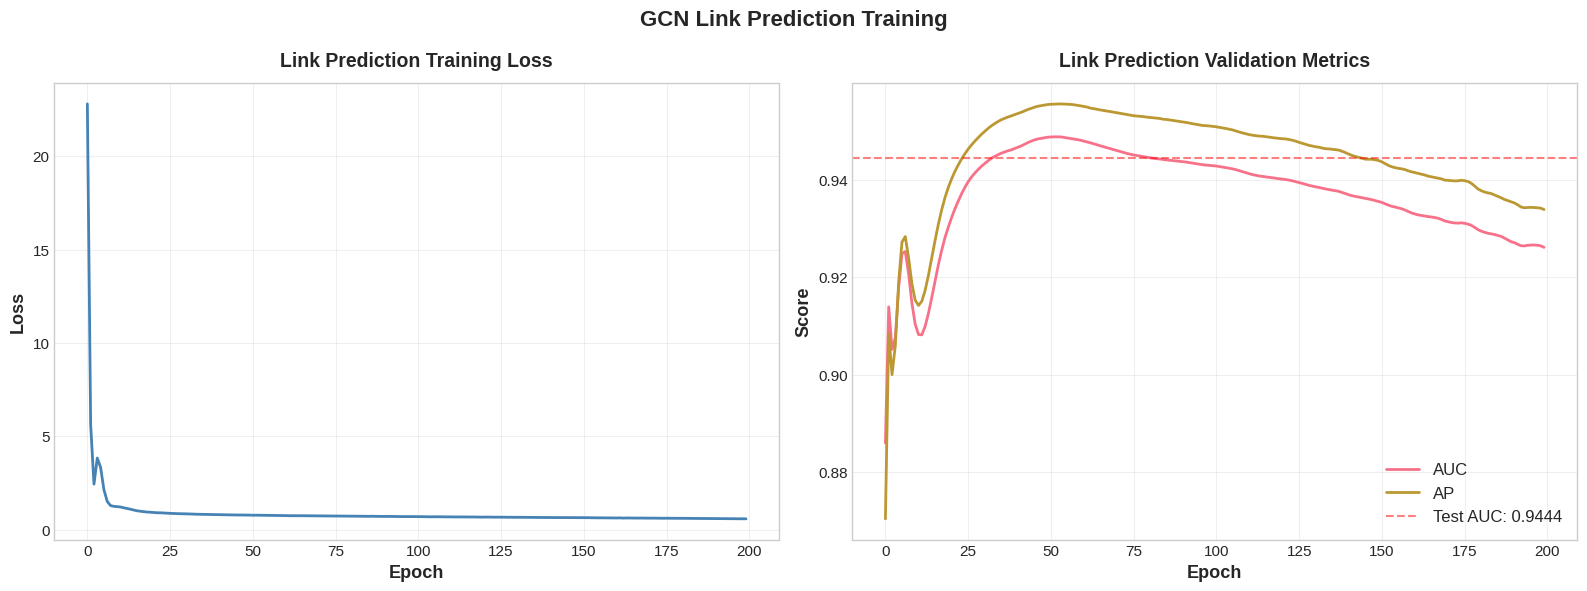

In [54]:
# Test evaluation
test_auc, test_ap = eval_lp(model_lp, X_tensor, A_hat_train_tensor,
                             test_pos_idx, test_neg_idx)

print("=== Link Prediction Test Results ===")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Test AP:   {test_ap:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lp_history['loss'], linewidth=2, color='steelblue')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Loss', fontsize=13)
axes[0].set_title('Link Prediction Training Loss', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(lp_history['val_auc'], label='AUC', linewidth=2)
axes[1].plot(lp_history['val_ap'], label='AP', linewidth=2)
axes[1].axhline(test_auc, color='red', linestyle='--', alpha=0.5, label=f'Test AUC: {test_auc:.4f}')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Score', fontsize=13)
axes[1].set_title('Link Prediction Validation Metrics', fontsize=14, pad=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GCN Link Prediction Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

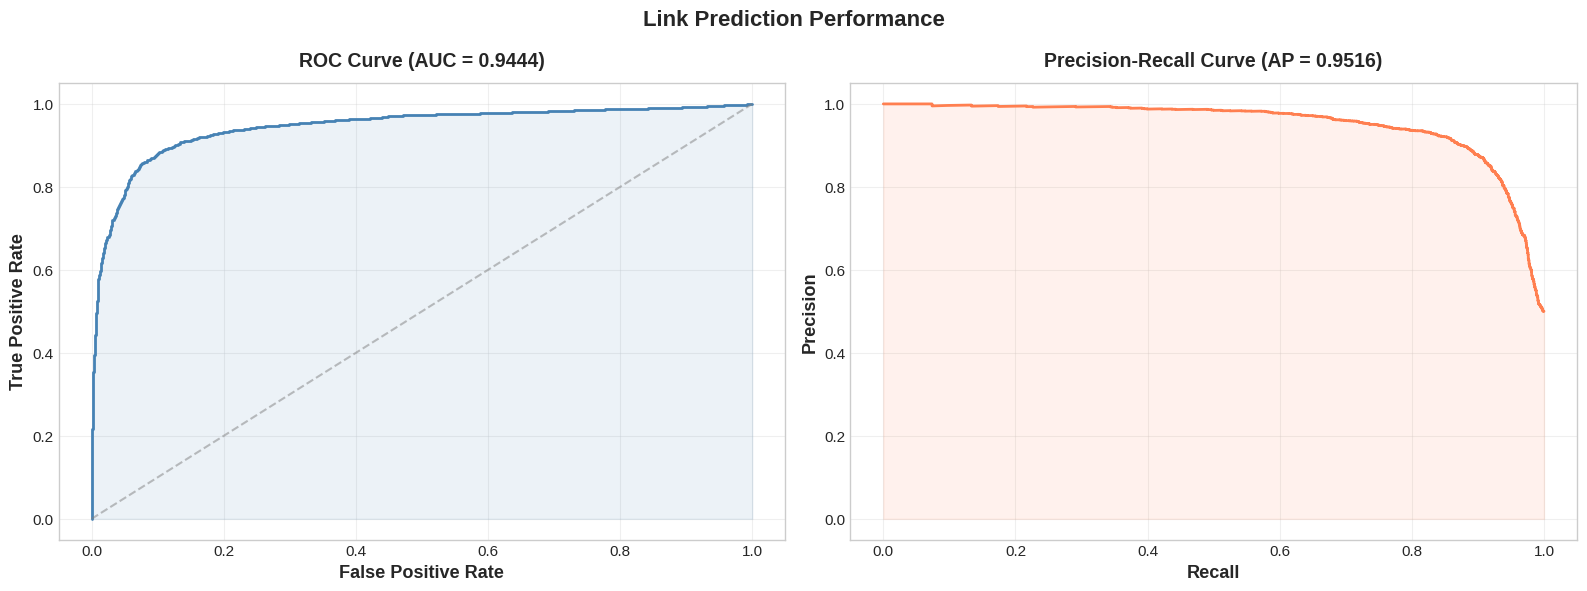

In [55]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Get test predictions
model_lp.eval()
with torch.no_grad():
    z_lp = model_lp.encode(X_tensor, A_hat_train_tensor)
    pos_scores = model_lp.decode(z_lp, test_pos_idx).cpu().numpy()
    neg_scores = model_lp.decode(z_lp, test_neg_idx).cpu().numpy()

y_true_test = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
y_scores_test = np.concatenate([torch.sigmoid(torch.tensor(pos_scores)).numpy(),
                                 torch.sigmoid(torch.tensor(neg_scores)).numpy()])

fpr, tpr, _ = roc_curve(y_true_test, y_scores_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_true_test, y_scores_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, linewidth=2, color='steelblue')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title(f'ROC Curve (AUC = {test_auc:.4f})', fontsize=14, pad=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_curve, precision_curve, linewidth=2, color='coral')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='coral')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title(f'Precision-Recall Curve (AP = {test_ap:.4f})', fontsize=14, pad=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Link Prediction Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Computing ranking metrics on test edges (this may take a minute)...

=== Link Prediction Ranking Metrics (Test Set) ===
Mean Rank (MR):              494.72  (out of 7624 nodes)
Mean Reciprocal Rank (MRR):  0.0300
Hits@1:                      0.0047  (0.47%)
Hits@3:                      0.0173  (1.73%)
Hits@5:                      0.0324  (3.24%)
Hits@10:                     0.0655  (6.55%)

Computed in 0.2s over 2780 test edges


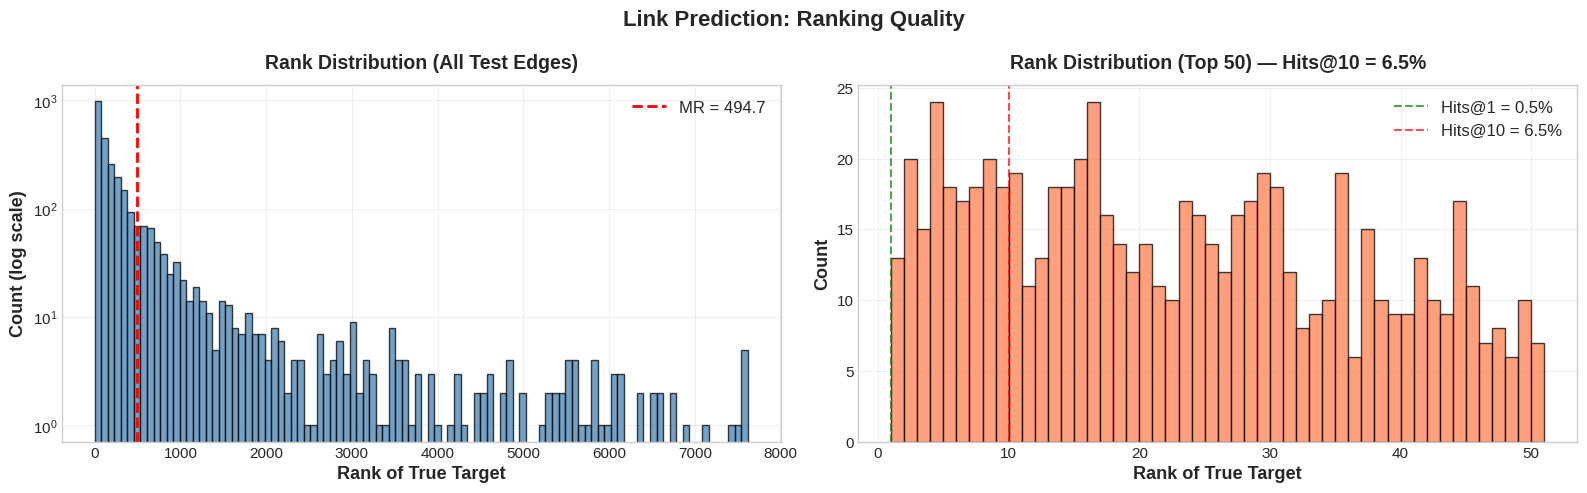

In [56]:

# === Ranking-Based Evaluation: MR, MRR, Hits@K ===
# For each test positive edge (u, v), we rank the true target v against ALL other
# nodes by their dot-product score with u. This tells us how well the model
# distinguishes the real neighbor from all possible candidates.

@torch.no_grad()
def compute_ranking_metrics(model, X, A_hat, test_pos_edges, node_to_idx, n_nodes, device, batch_size=512):
    """
    For each positive test edge (u, v):
      - Compute score(u, w) for ALL w in the graph
      - Find the rank of the true target v
    Then compute MR, MRR, and Hits@K.
    """
    model.eval()
    z = model.encode(X, A_hat)  # (n_nodes, emb_dim)

    ranks = []

    # Process in batches to avoid memory issues
    for start in range(0, len(test_pos_edges), batch_size):
        batch_edges = test_pos_edges[start:start + batch_size]

        for u, v in batch_edges:
            u_idx = node_to_idx[u]
            v_idx = node_to_idx[v]

            # Score of source node u against ALL nodes
            u_emb = z[u_idx].unsqueeze(0)          # (1, emb_dim)
            all_scores = (u_emb * z).sum(dim=1)     # (n_nodes,)

            # Rank of true target v (1-based, lower is better)
            true_score = all_scores[v_idx].item()
            rank = (all_scores > true_score).sum().item() + 1
            ranks.append(rank)

    ranks = np.array(ranks, dtype=np.float64)

    mr = ranks.mean()
    mrr = (1.0 / ranks).mean()
    hits_at_1 = (ranks <= 1).mean()
    hits_at_3 = (ranks <= 3).mean()
    hits_at_5 = (ranks <= 5).mean()
    hits_at_10 = (ranks <= 10).mean()

    return {
        'MR': mr,
        'MRR': mrr,
        'Hits@1': hits_at_1,
        'Hits@3': hits_at_3,
        'Hits@5': hits_at_5,
        'Hits@10': hits_at_10,
        'ranks': ranks
    }


print("Computing ranking metrics on test edges (this may take a minute)...")
t0 = time.time()
ranking_results = compute_ranking_metrics(
    model_lp, X_tensor, A_hat_train_tensor,
    test_pos_edges, node_to_idx, n_nodes, device
)
elapsed = time.time() - t0

print(f"\n=== Link Prediction Ranking Metrics (Test Set) ===")
print(f"Mean Rank (MR):              {ranking_results['MR']:.2f}  (out of {n_nodes} nodes)")
print(f"Mean Reciprocal Rank (MRR):  {ranking_results['MRR']:.4f}")
print(f"Hits@1:                      {ranking_results['Hits@1']:.4f}  ({ranking_results['Hits@1']*100:.2f}%)")
print(f"Hits@3:                      {ranking_results['Hits@3']:.4f}  ({ranking_results['Hits@3']*100:.2f}%)")
print(f"Hits@5:                      {ranking_results['Hits@5']:.4f}  ({ranking_results['Hits@5']*100:.2f}%)")
print(f"Hits@10:                     {ranking_results['Hits@10']:.4f}  ({ranking_results['Hits@10']*100:.2f}%)")
print(f"\nComputed in {elapsed:.1f}s over {len(test_pos_edges)} test edges")

# Rank distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full distribution (log scale)
axes[0].hist(ranking_results['ranks'], bins=100, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].set_yscale('log')
axes[0].set_xlabel('Rank of True Target', fontsize=13)
axes[0].set_ylabel('Count (log scale)', fontsize=13)
axes[0].set_title('Rank Distribution (All Test Edges)', fontsize=14, pad=12)
axes[0].axvline(ranking_results['MR'], color='red', linestyle='--', linewidth=2,
                label=f"MR = {ranking_results['MR']:.1f}")
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Zoomed-in: top 50 ranks
top_ranks = ranking_results['ranks'][ranking_results['ranks'] <= 50]
axes[1].hist(top_ranks, bins=range(1, 52), color='coral', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Rank of True Target', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title(f'Rank Distribution (Top 50) — Hits@10 = {ranking_results["Hits@10"]*100:.1f}%', fontsize=14, pad=12)
axes[1].axvline(1, color='green', linestyle='--', alpha=0.7, label=f'Hits@1 = {ranking_results["Hits@1"]*100:.1f}%')
axes[1].axvline(10, color='red', linestyle='--', alpha=0.7, label=f'Hits@10 = {ranking_results["Hits@10"]*100:.1f}%')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Link Prediction: Ranking Quality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 7. Community Detection from GNN Embeddings

### Why This Step?

The GCN models above were trained for specific tasks (classification and link prediction), not directly for community detection. But the hidden layer embeddings they learned might still encode community structure. So we extract those embeddings and run K-means clustering on them to detect communities.

This lets us compare:
- Do embeddings trained for classification find the same communities as spectral clustering or Node2Vec?
- Do link prediction embeddings (which focus on connection patterns) give better communities than classification embeddings (which focus on separating classes)?

We use K-means with k=18 (the number of true country labels) so the comparison is fair across all methods.

---


In [57]:
# Extract embeddings from both GCN models

# 1. Node classification GCN embeddings (already computed)
gcn_nc_emb = gcn_embeddings  # 64-dim hidden representations

# 2. Link prediction GCN embeddings
model_lp.eval()
with torch.no_grad():
    gcn_lp_emb = model_lp.encode(X_tensor, A_hat_tensor).cpu().numpy()

print(f"Node classification GCN embeddings: {gcn_nc_emb.shape}")
print(f"Link prediction GCN embeddings: {gcn_lp_emb.shape}")

# K-means on both embedding sets
results_gcn_comm = {}

for name, emb in [('GCN (Node Classif.)', gcn_nc_emb),
                   ('GCN (Link Pred.)', gcn_lp_emb)]:
    kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
    labels = kmeans.fit_predict(emb)

    communities = defaultdict(set)
    for i, lab in enumerate(labels):
        communities[lab].add(nodes[i])
    comm_list = list(communities.values())

    mod = nx_community.modularity(G, comm_list)
    nmi = normalized_mutual_info_score(y, labels)
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)

    results_gcn_comm[name] = {
        'labels': labels, 'modularity': mod,
        'nmi': nmi, 'ari': ari, 'ami': ami, 'embedding': emb
    }

    print(f"\n=== {name} -> K-Means (k={n_classes}) ===")
    print(f"Modularity: {mod:.4f}")
    print(f"NMI: {nmi:.4f}, ARI: {ari:.4f}, AMI: {ami:.4f}")

Node classification GCN embeddings: (7624, 64)
Link prediction GCN embeddings: (7624, 64)

=== GCN (Node Classif.) -> K-Means (k=18) ===
Modularity: 0.4508
NMI: 0.5912, ARI: 0.3663, AMI: 0.5878

=== GCN (Link Pred.) -> K-Means (k=18) ===
Modularity: 0.6515
NMI: 0.4897, ARI: 0.2559, AMI: 0.4856


---

## 8. Comprehensive Comparison

Now we put everything together and compare all methods side by side: the **Part 1 baseline** (Louvain) against all the **Part 2 methods** (Spectral Clustering, Node2Vec, GCN).

This is the key comparison because it tells us whether the more advanced methods from the lectures actually do better than the simple Louvain algorithm we started with. We compare on both intrinsic metrics (modularity) and external metrics (NMI, ARI, AMI) that measure alignment with the true country labels.

---


In [58]:
# Re-run Louvain as Part 1 baseline
partition_louvain = community_louvain.best_partition(G)
communities_louvain = defaultdict(set)
for node, comm_id in partition_louvain.items():
    communities_louvain[comm_id].add(node)
louvain_comm_list = list(communities_louvain.values())

louvain_labels = np.array([partition_louvain[n] for n in nodes])

mod_louvain = nx_community.modularity(G, louvain_comm_list)
nmi_louvain = normalized_mutual_info_score(y, louvain_labels)
ari_louvain = adjusted_rand_score(y, louvain_labels)
ami_louvain = adjusted_mutual_info_score(y, louvain_labels)

print("=== Louvain Baseline (Part 1) ===")
print(f"Communities detected: {len(louvain_comm_list)}")
print(f"Modularity: {mod_louvain:.4f}")
print(f"NMI: {nmi_louvain:.4f}, ARI: {ari_louvain:.4f}, AMI: {ami_louvain:.4f}")

=== Louvain Baseline (Part 1) ===
Communities detected: 28
Modularity: 0.8149
NMI: 0.6152, ARI: 0.5348, AMI: 0.6108


In [59]:
# Build comprehensive comparison table
spec_key_gt = f'GT-matched (k={n_classes})'

comparison_data = {
    'Method': [
        'Louvain (Part 1)',
        f'Spectral (k={n_classes})',
        'Node2Vec BFS (p=1,q=2)',
        'Node2Vec DFS (p=2,q=0.5)',
        'GCN (Node Classif.)',
        'GCN (Link Pred.)'
    ],
    'Type': [
        'Classical', 'Spectral', 'Shallow Emb.', 'Shallow Emb.', 'GNN', 'GNN'
    ],
    'Clusters': [
        len(louvain_comm_list),
        n_classes,
        n_classes,
        n_classes,
        n_classes,
        n_classes
    ],
    'Modularity': [
        mod_louvain,
        results_spectral[spec_key_gt]['modularity'],
        results_n2v['Node2Vec BFS (p=1,q=2)']['modularity'],
        results_n2v['Node2Vec DFS (p=2,q=0.5)']['modularity'],
        results_gcn_comm['GCN (Node Classif.)']['modularity'],
        results_gcn_comm['GCN (Link Pred.)']['modularity']
    ],
    'NMI': [
        nmi_louvain,
        results_spectral[spec_key_gt]['nmi'],
        results_n2v['Node2Vec BFS (p=1,q=2)']['nmi'],
        results_n2v['Node2Vec DFS (p=2,q=0.5)']['nmi'],
        results_gcn_comm['GCN (Node Classif.)']['nmi'],
        results_gcn_comm['GCN (Link Pred.)']['nmi']
    ],
    'ARI': [
        ari_louvain,
        results_spectral[spec_key_gt]['ari'],
        results_n2v['Node2Vec BFS (p=1,q=2)']['ari'],
        results_n2v['Node2Vec DFS (p=2,q=0.5)']['ari'],
        results_gcn_comm['GCN (Node Classif.)']['ari'],
        results_gcn_comm['GCN (Link Pred.)']['ari']
    ],
    'AMI': [
        ami_louvain,
        results_spectral[spec_key_gt]['ami'],
        results_n2v['Node2Vec BFS (p=1,q=2)']['ami'],
        results_n2v['Node2Vec DFS (p=2,q=0.5)']['ami'],
        results_gcn_comm['GCN (Node Classif.)']['ami'],
        results_gcn_comm['GCN (Link Pred.)']['ami']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 100)
print("COMPREHENSIVE COMPARISON: Community Detection Methods")
print("=" * 100)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))
print("=" * 100)

# Best performers
print("\n=== Best Performers ===")
for metric in ['Modularity', 'NMI', 'ARI', 'AMI']:
    best_idx = comparison_df[metric].idxmax()
    print(f"{metric:12s}: {comparison_df.loc[best_idx, 'Method']:30s} ({comparison_df.loc[best_idx, metric]:.4f})")

COMPREHENSIVE COMPARISON: Community Detection Methods
                  Method         Type  Clusters  Modularity    NMI    ARI    AMI
        Louvain (Part 1)    Classical        28      0.8149 0.6152 0.5348 0.6108
         Spectral (k=18)     Spectral        18      0.7992 0.6586 0.6714 0.6557
  Node2Vec BFS (p=1,q=2) Shallow Emb.        18      0.7816 0.6171 0.5024 0.6141
Node2Vec DFS (p=2,q=0.5) Shallow Emb.        18      0.7844 0.6107 0.4549 0.6077
     GCN (Node Classif.)          GNN        18      0.4508 0.5912 0.3663 0.5878
        GCN (Link Pred.)          GNN        18      0.6515 0.4897 0.2559 0.4856

=== Best Performers ===
Modularity  : Louvain (Part 1)               (0.8149)
NMI         : Spectral (k=18)                (0.6586)
ARI         : Spectral (k=18)                (0.6714)
AMI         : Spectral (k=18)                (0.6557)


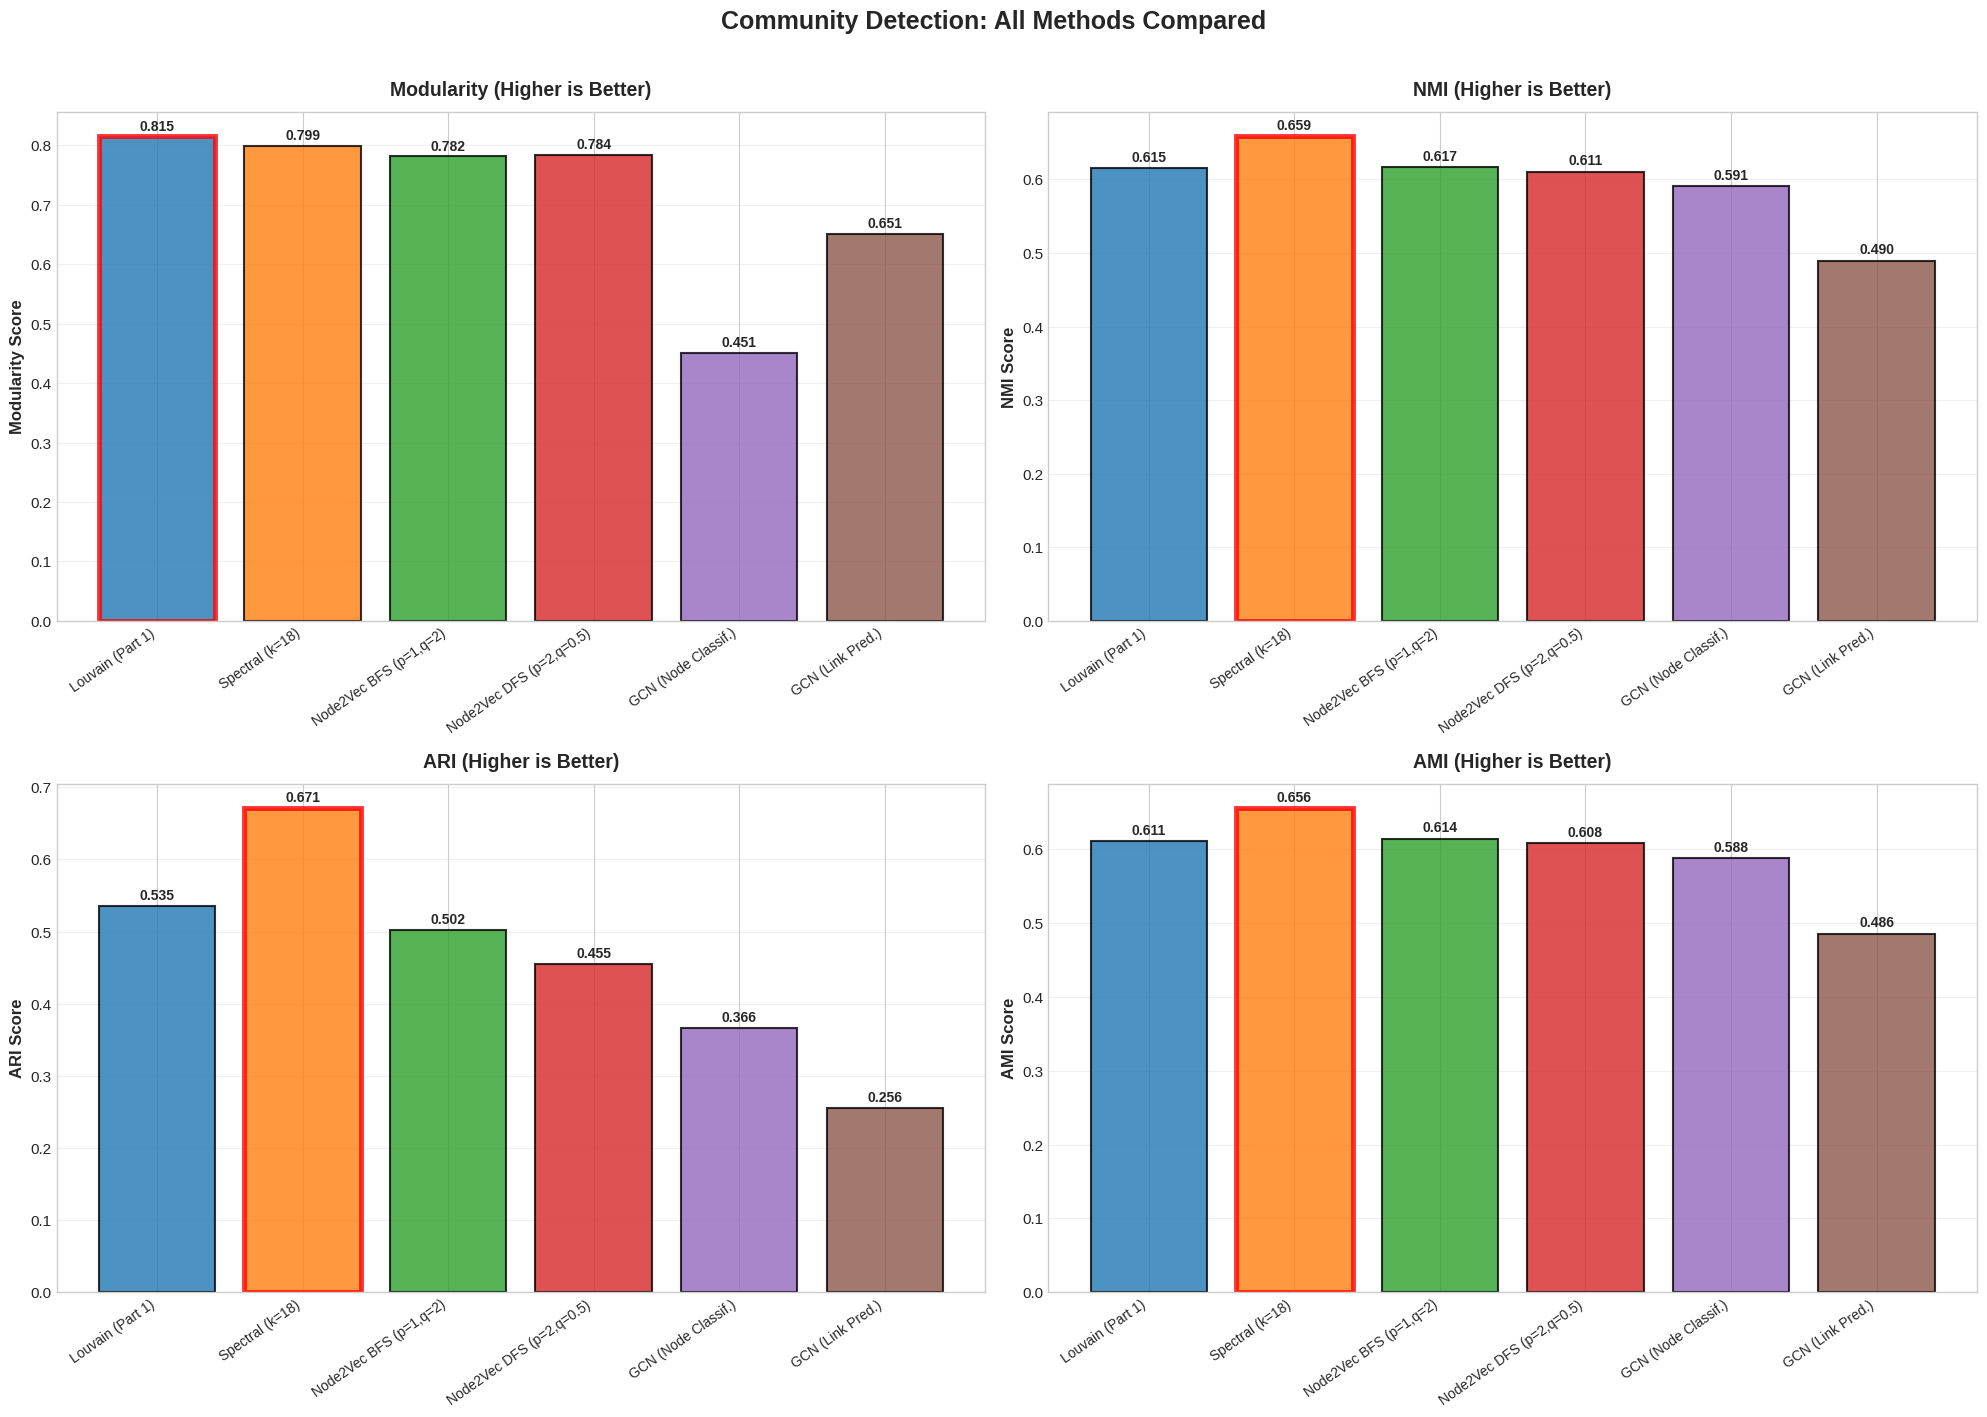

Red borders indicate best-performing method for each metric.


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

methods = comparison_df['Method'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
metrics_to_plot = ['Modularity', 'NMI', 'ARI', 'AMI']
subtitles = ['Higher is Better', 'Higher is Better', 'Higher is Better', 'Higher is Better']

for idx, (metric, subtitle) in enumerate(zip(metrics_to_plot, subtitles)):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values

    bars = ax.bar(range(len(methods)), values, color=colors, alpha=0.8,
                  edgecolor='black', linewidth=1.5)

    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=35, ha='right', fontsize=10)
    ax.set_ylabel(f'{metric} Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} ({subtitle})', fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='y')

    # Value labels
    for i, (bar, v) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Highlight best
    best_idx_metric = np.argmax(values)
    bars[best_idx_metric].set_edgecolor('red')
    bars[best_idx_metric].set_linewidth(3.5)

plt.suptitle('Community Detection: All Methods Compared',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Red borders indicate best-performing method for each metric.")

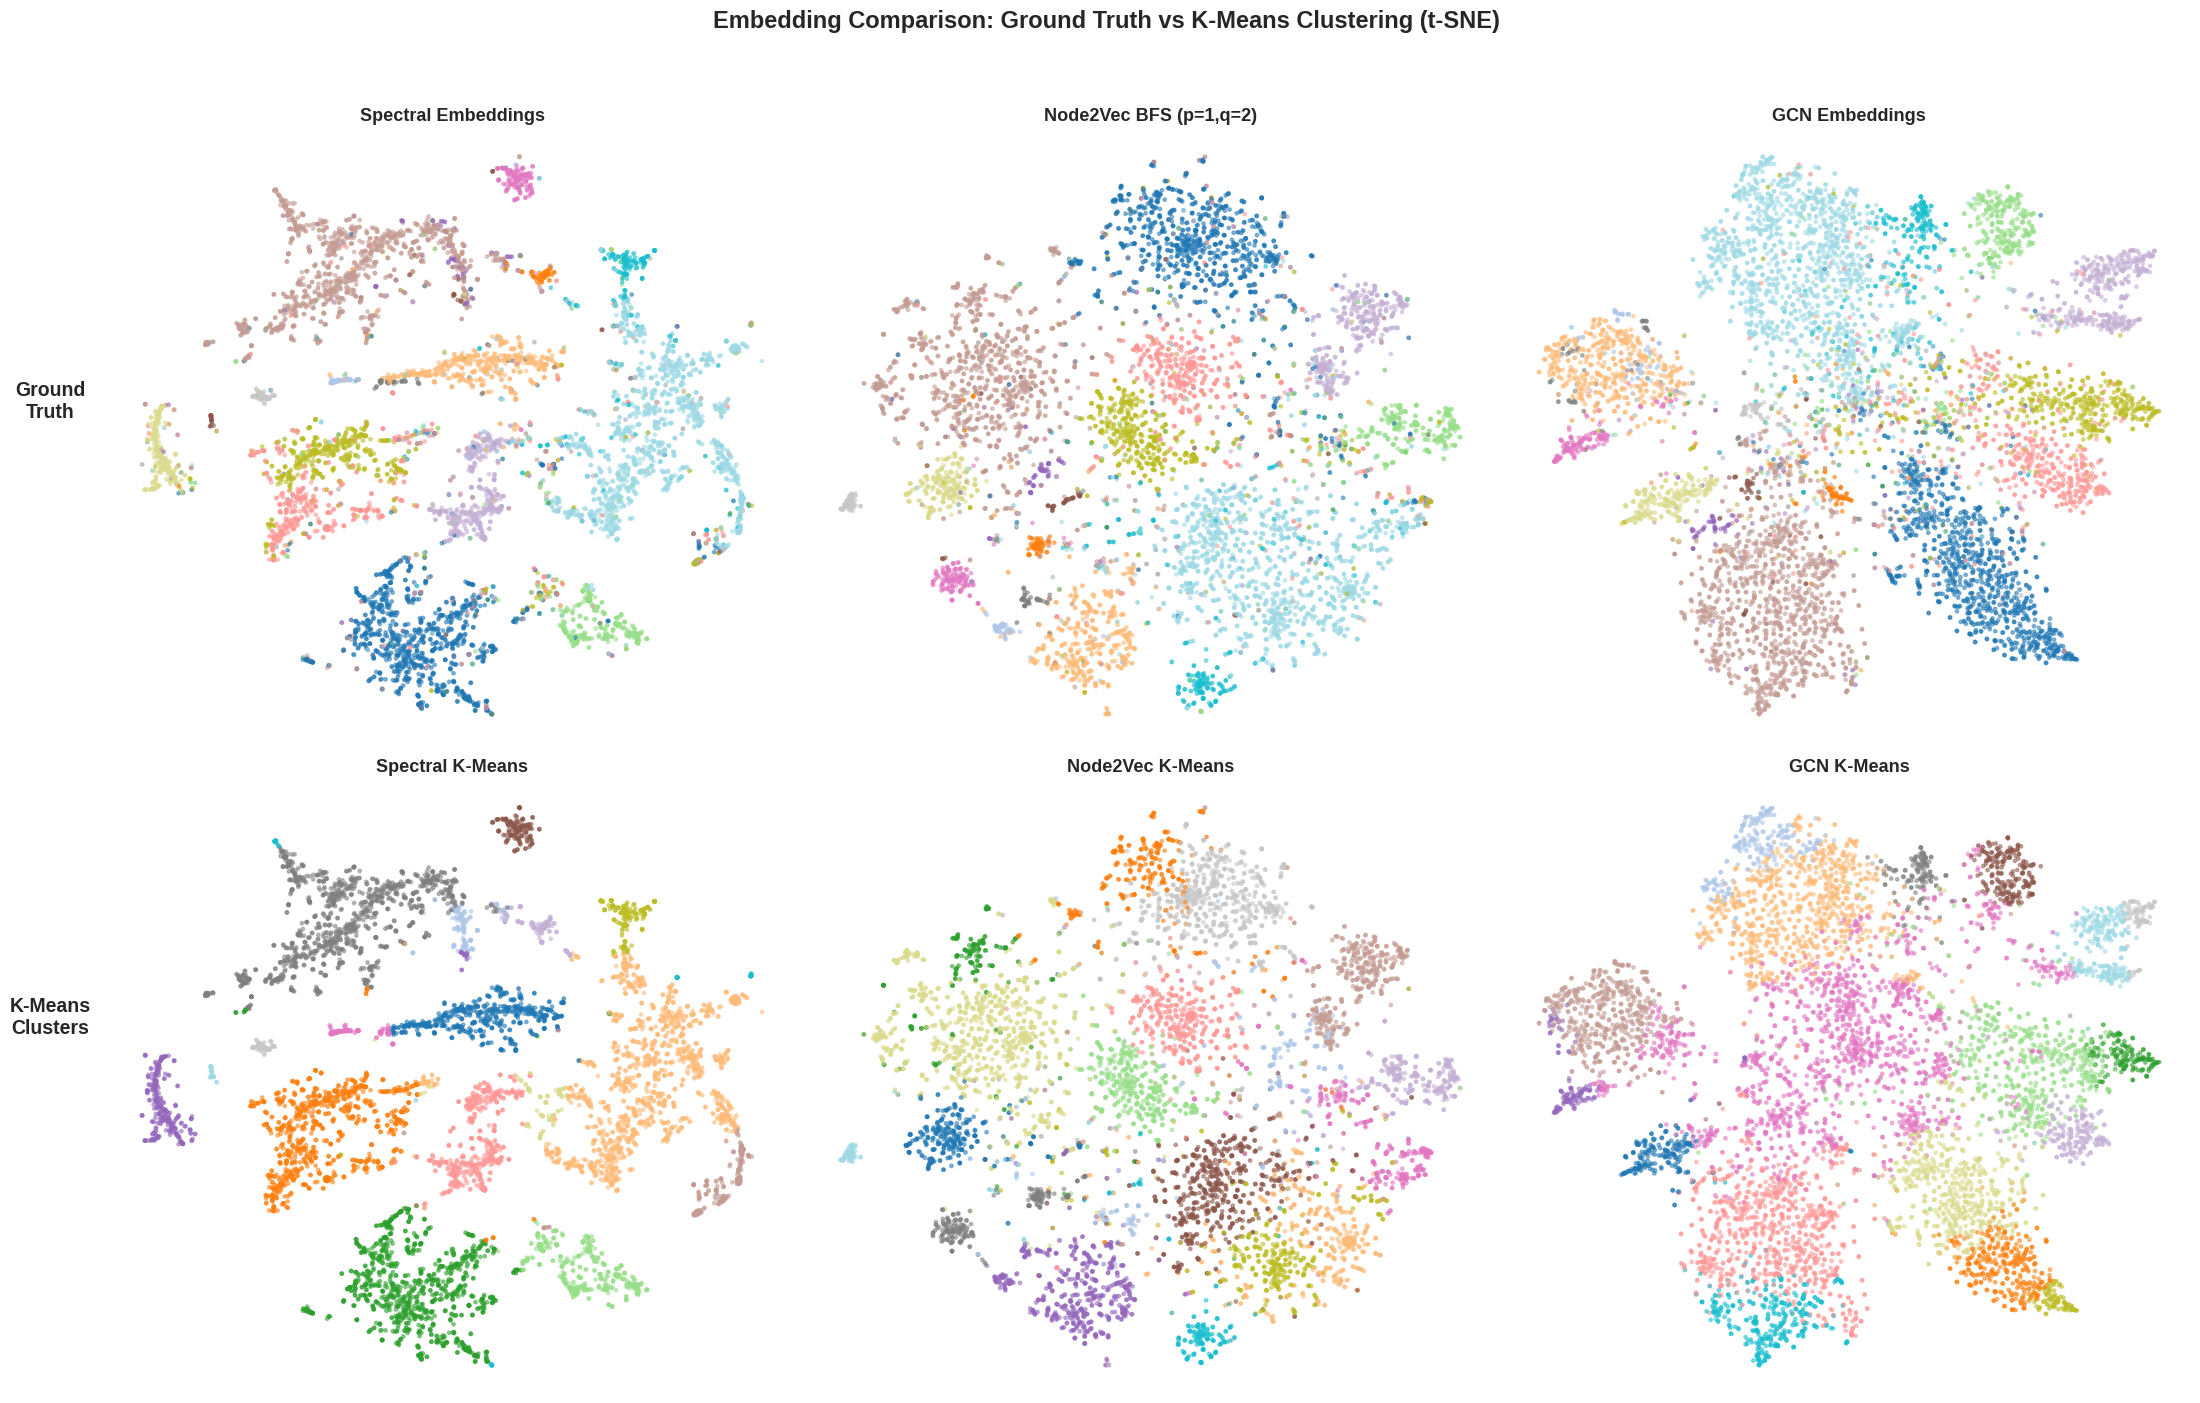

In [61]:
# Side-by-side t-SNE comparison of all embedding methods
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Row 1: Colored by ground truth
# Spectral
axes[0, 0].scatter(spec_2d[:, 0], spec_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 0].set_title('Spectral Embeddings', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# Node2Vec BFS
axes[0, 1].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 1].set_title('Node2Vec BFS (p=1,q=2)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# GCN
axes[0, 2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=y, cmap='tab20', s=6, alpha=0.5)
axes[0, 2].set_title('GCN Embeddings', fontsize=13, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Colored by K-means labels
spec_km_labels = results_spectral[spec_key_gt]['labels']
bfs_km_labels = results_n2v['Node2Vec BFS (p=1,q=2)']['labels']
gcn_km_labels = results_gcn_comm['GCN (Node Classif.)']['labels']

axes[1, 0].scatter(spec_2d[:, 0], spec_2d[:, 1], c=spec_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 0].set_title('Spectral K-Means', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].scatter(bfs_2d[:, 0], bfs_2d[:, 1], c=bfs_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 1].set_title('Node2Vec K-Means', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].scatter(gcn_2d[:, 0], gcn_2d[:, 1], c=gcn_km_labels, cmap='tab20', s=6, alpha=0.5)
axes[1, 2].set_title('GCN K-Means', fontsize=13, fontweight='bold')
axes[1, 2].axis('off')

fig.text(0.02, 0.72, 'Ground\nTruth', fontsize=14, fontweight='bold',
         ha='center', va='center', rotation=0)
fig.text(0.02, 0.28, 'K-Means\nClusters', fontsize=14, fontweight='bold',
         ha='center', va='center', rotation=0)

plt.suptitle('Embedding Comparison: Ground Truth vs K-Means Clustering (t-SNE)',
             fontsize=17, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0.04, 0, 1, 0.97])
plt.show()

In [62]:

# Additional summary: GCN node classification and link prediction results
print("=" * 80)
print("ADDITIONAL RESULTS: GCN Task Performance")
print("=" * 80)

print(f"\n--- Node Classification (GCN) ---")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Macro F1:       {f1_score(test_true, test_pred, average='macro'):.4f}")
print(f"Weighted F1:    {f1_score(test_true, test_pred, average='weighted'):.4f}")

print(f"\n--- Link Prediction (GCN) ---")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test AP:        {test_ap:.4f}")

print(f"\n--- Link Prediction Ranking Metrics ---")
print(f"Mean Rank (MR):              {ranking_results['MR']:.2f}  (out of {n_nodes} nodes)")
print(f"Mean Reciprocal Rank (MRR):  {ranking_results['MRR']:.4f}")
print(f"Hits@1:   {ranking_results['Hits@1']*100:.2f}%")
print(f"Hits@3:   {ranking_results['Hits@3']*100:.2f}%")
print(f"Hits@5:   {ranking_results['Hits@5']*100:.2f}%")
print(f"Hits@10:  {ranking_results['Hits@10']*100:.2f}%")

print(f"\n--- Summary ---")
print("The GCN leverages both graph structure AND node features (artist preferences),")
print("while Louvain and spectral methods use only the graph topology.")
print("Node2Vec captures structure via random walks but ignores node features.")
print("\nThis comparison shows the value of incorporating features alongside structure.")


ADDITIONAL RESULTS: GCN Task Performance

--- Node Classification (GCN) ---
Test Accuracy:  0.8952
Macro F1:       0.8227
Weighted F1:    0.8925

--- Link Prediction (GCN) ---
Test AUC:       0.9444
Test AP:        0.9516

--- Link Prediction Ranking Metrics ---
Mean Rank (MR):              494.72  (out of 7624 nodes)
Mean Reciprocal Rank (MRR):  0.0300
Hits@1:   0.47%
Hits@3:   1.73%
Hits@5:   3.24%
Hits@10:  6.55%

--- Summary ---
The GCN leverages both graph structure AND node features (artist preferences),
while Louvain and spectral methods use only the graph topology.
Node2Vec captures structure via random walks but ignores node features.

This comparison shows the value of incorporating features alongside structure.



---

## 9. Discussion and Conclusions

### 9.1 The Big Picture: Louvain Is Still Hard to Beat

Here are the community detection results side by side:

| Method | Type | Modularity | NMI | ARI | AMI |
|--------|------|-----------|-----|-----|-----|
| **Louvain (Part 1)** | Classical | **0.8149** | 0.6152 | 0.5348 | 0.6108 |
| **Spectral (k=18)** | Spectral | 0.7992 | **0.6586** | **0.6714** | **0.6557** |
| Node2Vec BFS (p=1,q=2) | Shallow Emb. | 0.7816 | 0.6171 | 0.5024 | 0.6141 |
| Node2Vec DFS (p=2,q=0.5) | Shallow Emb. | 0.7844 | 0.6107 | 0.4549 | 0.6077 |
| GCN (Node Classif.) | GNN | 0.4508 | 0.5912 | 0.3663 | 0.5878 |
| GCN (Link Pred.) | GNN | 0.6515 | 0.4897 | 0.2559 | 0.4856 |

The honest takeaway: **Louvain, a simple classical method from Part 1, beats both GCN and Node2Vec on modularity and is very competitive on NMI/ARI.** Only spectral clustering manages to beat it on the ground truth alignment metrics (NMI, ARI, AMI), and even that is close. The GCN-based community detection actually performs the worst.

**This is a clear sign that we need to do better with the GNN and embedding approaches.** The fact that a simple greedy algorithm outperforms more sophisticated deep learning methods suggests something is off - either with our setup, our dataset, or both.

### 9.2 Why Did Spectral Clustering Do the Best on Ground Truth?

Spectral clustering gave us the best alignment with the true country labels (NMI=0.659, ARI=0.671). We think this is because:
- It directly uses the mathematical structure of the graph (Laplacian eigenvectors) in a principled way
- It does not have hyperparameters to tune (unlike Node2Vec) or training instability (unlike GCN)
- The eigengap heuristic suggested k=7, meaning the graph naturally has about 7 big clusters - but when we force k=18, it still does a good job splitting them further

### 9.3 Why Did GCN and Node2Vec Lose to Louvain?

This is the most important question. Here is what we think:

**For GCN:** The embeddings from node classification (modularity=0.45) and link prediction (modularity=0.65) are clearly not optimized for community detection. The classification GCN learns to separate countries, not to find dense subgraphs. The link prediction GCN learns to predict edges, which is closer but still not the same objective as maximizing modularity. **The GCN is not bad at what it is trained for (89.5% classification accuracy, 94.4% link prediction AUC), but its embeddings do not transfer well to community detection.**

**For Node2Vec:** Both configurations (NMI ~0.61) are competitive with Louvain (NMI=0.615) on ground truth alignment but lose on modularity (0.78 vs 0.81). The gap is not huge, but the fact that a simple greedy method matches or beats a learned embedding approach is disappointing.

**Possible reasons this is happening:**
- **The dataset might be too small.** With only 7,624 nodes, the graph may not have enough complexity for deep learning methods to show their advantage. GCNs and embedding methods tend to shine on larger, more complex networks where simple methods struggle.
- **The features might not help for community detection.** Even though artist preferences are great for predicting countries (89.5% accuracy), they may not add anything for finding structural communities. The graph structure alone might be enough for this network.
- **The LastFM network might be too well-structured.** If the communities are already very clear in the graph topology, a simple method like Louvain can find them without needing fancy embeddings. The high modularity (0.81) suggests the communities are very well-separated.

### 9.4 Link Prediction: Good AUC but Poor Ranking

The link prediction GCN achieves strong binary classification metrics:
- **Test AUC: 0.944** and **Test AP: 0.952** - meaning the model is very good at telling real edges from random non-edges

However, the **ranking-based metrics** paint a very different picture:

| Metric | Value |
|--------|-------|
| Mean Rank (MR) | 494.72 (out of 7,624 nodes) |
| Mean Reciprocal Rank (MRR) | 0.0300 |
| Hits@1 | 0.47% |
| Hits@3 | 1.73% |
| Hits@5 | 3.24% |
| Hits@10 | 6.55% |

These ranking numbers are quite low. An MR of ~495 means that on average, the true neighbor is ranked around position 495 out of 7,624 candidates. Only 0.47% of the time does the model rank the true neighbor first (Hits@1), and only 6.55% of the time is the true neighbor in the top 10 (Hits@10). The MRR of 0.03 is also low.

**Why the gap between AUC and ranking metrics?** AUC measures how well the model separates positive from negative examples when both are provided. Ranking metrics are much harder - for each real edge (u, v), the model has to pick out v from **all** 7,624 possible nodes. The model can tell that a real edge scores higher than a random non-edge (high AUC), but when ranking among all nodes, many non-neighbors still get high scores, pushing the true target down in the ranking.

**What this tells us:** The GCN link predictor learns a useful signal but not a very precise one. For practical link prediction (e.g., "recommend the most likely friend"), we would need much higher Hits@K values. This is another area where we expect a bigger or more complex dataset might yield better results, since the model would have more training signal to learn from.

### 9.5 Node2Vec: BFS vs DFS

The BFS-biased configuration (p=1, q=2) outperformed DFS (p=2, q=0.5) on ARI but they are close on NMI:

| Config | NMI | ARI |
|--------|-----|-----|
| BFS (p=1, q=2) | 0.6171 | 0.5024 |
| DFS (p=2, q=0.5) | 0.6107 | 0.4549 |

BFS does slightly better here, suggesting that local neighborhood structure matters more than global exploration for this particular network. But the difference is small, so we should not over-interpret this with just one dataset.

### 9.6 GCN Works Great for Supervised Tasks, Just Not for Community Detection

It is important to note that the GCN is not a failure overall:
- **Node classification:** 89.5% test accuracy, macro F1 = 0.823 - it can predict which country a user is from very well
- **Link prediction:** AUC = 0.944, AP = 0.952 - it can distinguish real edges from random non-edges very well

The problem is specifically with using GCN embeddings for unsupervised community detection. The embeddings are optimized for their training task, not for finding communities. This is a known issue and suggests we might want to look into methods that are specifically designed for community detection with GNNs (like DMoN or MinCutPool).

### 9.7 What We Learned Compared to Part 1

1. **Modularity is not everything.** In Part 1, Louvain won on modularity and we had no way to know if those communities were "real". Now with ground truth, we see that spectral clustering actually finds more meaningful communities despite slightly lower modularity.
2. **More complex does not mean better.** The GCN, which is the most complex method, performs the worst for community detection. Simpler methods work better here.
3. **Features help for classification but not for community detection** on this particular dataset.

### 9.8 Major Limitation: We Only Tested on One Dataset

**This is the biggest caveat of our results so far.** Everything above is based on the LastFM Asia social network only. We need to test on the **Cisco network data** and ideally on a **larger dataset** as well before drawing general conclusions.

Why this matters:
- **The LastFM network is relatively small** (7,624 nodes). GCN and Node2Vec methods are known to improve with scale. On a bigger, more complex network, these methods might outperform Louvain.
- **The LastFM network has very clear community structure** (modularity > 0.8). On a messier network like Cisco, where communities are not as well-separated, embedding methods might have a bigger advantage.
- **The Cisco data has different characteristics** (different types of nodes, different features, different scale). What works on a social network might not work on a computer network.
- **Seeing GCN and Node2Vec get beaten by Louvain tells us we need to do a better job.** It could be that the dataset's small size and clear structure just do not give the advanced methods room to shine. Or it could be that our hyperparameters and architectures need tuning. Either way, we need more experiments on different data to figure out which one it is.
- **The low ranking metrics (MRR=0.03, Hits@10=6.6%) also suggest the dataset may be limiting.** With more training edges and a larger graph, the link prediction model would have more signal to learn from and we would expect ranking performance to improve.

### 9.9 Limitations

- The GCN uses SVD-reduced features (128 dims from 7,842, keeping 39% of variance) - we lose some information here
- We only tried two Node2Vec configurations - there might be better hyperparameter settings
- There is a big class imbalance (the largest country has 98x more users than the smallest) which hurts both K-means and GCN for small classes
- Our GCN is simple (2 layers, 64 hidden dims) - a deeper or wider model might do better
- **Most importantly: these results are from one dataset only and may not generalize**

### 9.10 Next Steps

1. **Run these methods on the Cisco data** to see if the same patterns hold on a different type of network
2. **Try a larger dataset** to see if GCN and Node2Vec improve with scale
3. **Tune hyperparameters** more carefully, especially for Node2Vec (walk length, number of walks) and GCN (depth, width, learning rate)
4. **Improve link prediction ranking performance** - try different decoders (e.g., DistMult, TransE) or harder negative sampling strategies to push Hits@K and MRR higher
5. **Consider GNN methods designed specifically for community detection** (like DMoN or MinCutPool) rather than repurposing classification/link prediction embeddings

### 9.10 Conclusions (So Far)

1. **Spectral clustering is the best method for community detection** on this network (highest NMI=0.659, ARI=0.671). It works because it directly captures the mathematical structure of the graph.
2. **Louvain is still very competitive** (highest modularity=0.815, decent NMI=0.615). For a simple greedy algorithm, it is surprisingly hard to beat.
3. **Node2Vec is a solid middle ground** (NMI ~0.61) and gives us useful embeddings for visualization and other tasks.
4. **GCN is great for supervised tasks** (89.5% classification, 94.4% link prediction AUC) but its embeddings are not well-suited for unsupervised community detection.
5. **Link prediction ranking metrics are low** (MRR=0.03, Hits@10=6.6%), showing that high AUC does not mean the model can precisely identify the right neighbor out of all candidates.
6. **We cannot draw general conclusions yet** because we have only tested on one small, well-structured social network. The real test will be on the Cisco data and larger datasets.

---

## 10. References

1. **Spectral Clustering:** Von Luxburg, U. (2007). "A tutorial on spectral clustering." *Statistics and Computing*, 17(4), 395-416.

2. **Node2Vec:** Grover, A., & Leskovec, J. (2016). "node2vec: Scalable Feature Learning for Networks." *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '16)*.

3. **GCN:** Kipf, T. N., & Welling, M. (2017). "Semi-Supervised Classification with Graph Convolutional Networks." *International Conference on Learning Representations (ICLR)*.

4. **LastFM Dataset:** Rozemberczki, B., & Sarkar, R. (2020). "Characteristic Functions on Graphs: Birds of a Feather, from Statistical Descriptors to Parametric Models." *Proceedings of the 29th ACM International Conference on Information & Knowledge Management (CIKM '20)*.

5. **Word2Vec:** Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). "Distributed Representations of Words and Phrases and their Compositionality." *Advances in Neural Information Processing Systems (NeurIPS)*.

6. **Louvain:** Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). "Fast unfolding of communities in large networks." *Journal of Statistical Mechanics: Theory and Experiment*, 2008(10), P10008.
